In [1]:
# ---
# jupyter:
#   jupytext:
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#       jupytext_version: 1.19.1

#     language: python
#     name: python3
# ---

# Phần 2: Tiền xử lý dữ liệu dạng bảng – IEEE-CIS Fraud Detection
#
Dataset: IEEE-CIS Fraud Detection
- `train_transaction.csv`, `train_identity.csv`
- `test_transaction.csv`, `test_identity.csv`
- Bài toán phân loại nhị phân: dự đoán `isFraud`
- Dữ liệu có cả thuộc tính số và phân loại, nhiều giá trị thiếu, mất cân bằng lớp nghiêm trọng.

## 0. Cài đặt thư viện cần thiết

Nếu thiếu thư viện, cài thủ công:

```bash
pip install missingno pyampute category_encoders umap-learn imbalanced-learn scikit-learn scipy statsmodels
```

In [2]:
from scipy.stats import friedmanchisquare, wilcoxon
import json
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report)
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import f_classif, chi2, mutual_info_classif, RFE
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold
import category_encoders as ce
from scipy.stats import levene
from sklearn.preprocessing import (MinMaxScaler, StandardScaler,
                                   RobustScaler, QuantileTransformer)
from scipy.stats import ks_2samp
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import mutual_info_classif
import missingno as msno
from scipy import stats
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
import os

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 80
pd.options.display.max_rows = 60
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
SEED = 42
np.random.seed(SEED)

## 0. Load & merge dữ liệu

In [3]:
# ── Đường dẫn dữ liệu ──────────────────────────────────────────────────────

try:
    _SOURCE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    _SOURCE_DIR = Path.cwd().parent

DATA_DIR   = str(_SOURCE_DIR / 'data' / 'raw' / 'tabular')
OUTPUT_DIR = str(_SOURCE_DIR / 'data' / 'processed' / 'tabular')

# Fallback: nếu đường dẫn gốc không tồn tại, tìm thư mục chứa train_transaction.csv
if not os.path.exists(os.path.join(DATA_DIR, 'train_transaction.csv')):
    _candidates = [
        _SOURCE_DIR / 'data' / 'tabular',
        _SOURCE_DIR.parent / 'data' / 'tabular',
        _SOURCE_DIR.parent / 'data' / 'raw' / 'tabular',
    ]
    for _c in _candidates:
        if (_c / 'train_transaction.csv').exists():
            DATA_DIR = str(_c)
            print(f"[INFO] Dùng đường dẫn dự phòng: {DATA_DIR}")
            break
    else:
        raise FileNotFoundError(
            f"Không tìm thấy train_transaction.csv. "
            f"Đã thử các đường dẫn: {[str(c) for c in _candidates]}"
        )

os.makedirs(OUTPUT_DIR, exist_ok=True)
FIGURES_DIR = str(_SOURCE_DIR / 'outputs' / 'tabular')
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"DATA_DIR    = {DATA_DIR}")
print(f"OUTPUT_DIR  = {OUTPUT_DIR}")
print(f"FIGURES_DIR = {FIGURES_DIR}")

print("Đang tải dữ liệu...")
train_transaction = pd.read_csv(os.path.join(DATA_DIR, 'train_transaction.csv'))
train_identity    = pd.read_csv(os.path.join(DATA_DIR, 'train_identity.csv'))
test_transaction  = pd.read_csv(os.path.join(DATA_DIR, 'test_transaction.csv'))
test_identity     = pd.read_csv(os.path.join(DATA_DIR, 'test_identity.csv'))

# Merge transaction + identity theo TransactionID (left join)
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
test  = pd.merge(test_transaction,  test_identity,  on='TransactionID', how='left')

del train_transaction, train_identity, test_transaction, test_identity
gc.collect()

print(f"Train: {train.shape[0]:,} dòng x {train.shape[1]} cột")
print(f"Test : {test.shape[0]:,} dòng x {test.shape[1]} cột")

DATA_DIR    = d:\DataMining\DataPreprocessing\Source\data\raw\tabular
OUTPUT_DIR  = d:\DataMining\DataPreprocessing\Source\data\processed\tabular
FIGURES_DIR = d:\DataMining\DataPreprocessing\Source\outputs\tabular
Đang tải dữ liệu...
Train: 590,540 dòng x 434 cột
Test : 506,691 dòng x 433 cột


In [4]:
# ── Giảm sử dụng bộ nhớ (downcast kiểu dữ liệu) ──────────────────────────────
def reduce_mem_usage(df, verbose=True):
    """Giảm bộ nhớ bằng cách chuyển kiểu dtype nhỏ hơn."""
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                for dtype in [np.int8, np.int16, np.int32, np.int64]:
                    if c_min > np.iinfo(dtype).min and c_max < np.iinfo(dtype).max:
                        df[col] = df[col].astype(dtype)
                        break
            else:
                if (c_min > np.finfo(np.float32).min and
                        c_max < np.finfo(np.float32).max):
                    df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"  Bộ nhớ giảm từ {start_mem:.1f} MB -> {end_mem:.1f} MB "
              f"({100*(start_mem-end_mem)/start_mem:.1f}%)")
    return df


train = reduce_mem_usage(train)
test = reduce_mem_usage(test)
gc.collect()

  Bộ nhớ giảm từ 2514.0 MB -> 1603.3 MB (36.2%)
  Bộ nhớ giảm từ 2164.1 MB -> 1386.1 MB (35.9%)


0

#### Shape, dtypes, memory usage

In [5]:
print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}\n")

# Phân loại dtype
dtype_summary = train.dtypes.value_counts()
print("Kiểu dữ liệu:")
print(dtype_summary.to_string())

mem_mb = train.memory_usage(deep=True).sum() / 1024**2
print(f"\nBộ nhớ train: {mem_mb:.1f} MB")

Train shape : (590540, 434)
Test  shape : (506691, 433)

Kiểu dữ liệu:
float32    399
object      31
int32        2
int8         1
int16        1

Bộ nhớ train: 1603.3 MB


#### Phân nhóm cột theo ý nghĩa nghiệp vụ
#
Dataset IEEE-CIS gồm ~400 cột được Vesta Corporation đặt tên có chủ đích.
Ta có thể chia toàn bộ thuộc tính thành 9 nhóm dựa theo ý nghĩa nghiệp vụ:
#
| Nhóm | Cột đại diện | Ý nghĩa |
|---|---|---|
| **Transaction** | `TransactionDT`, `TransactionAmt`, `ProductCD` | Thông tin cơ bản của giao dịch: thời điểm, giá trị, loại sản phẩm |
| **Card** | `card1`–`card6` | Thông tin thẻ thanh toán: ID, mạng thẻ, loại thẻ, ngân hàng phát hành |
| **Address/Dist** | `addr1`, `addr2`, `dist1`, `dist2` | Địa chỉ thanh toán và khoảng cách địa lý liên quan |
| **Email** | `P_emaildomain`, `R_emaildomain` | Domain email của người mua (P) và người nhận (R) |
| **C (count)** | `C1`–`C14` | Đếm các sự kiện liên quan đến thẻ/địa chỉ (Vesta không công bố chi tiết) |
| **D (timedelta)** | `D1`–`D15` | Khoảng thời gian giữa các sự kiện (ngày từ giao dịch trước, từ khi mở thẻ, v.v.) |
| **M (match)** | `M1`–`M9` | Biến nhị phân "match": khớp tên, địa chỉ, v.v. giữa các bản ghi |
| **V (Vesta)** | `V1`–`V339` | Đặc trưng kỹ thuật do Vesta tính toán nội bộ (enriched features) |
| **Identity** | `id_01`–`id_38`, `DeviceType`, `DeviceInfo` | Thông tin thiết bị và danh tính: OS, trình duyệt, loại thiết bị |
#
### Tại sao phân nhóm như vậy?
#
1. Transaction: Ba cột thuần giao dịch tạo thành "xương sống": thời điểm (`TransactionDT`)
và giá trị (`TransactionAmt`) là hai đặc trưng quan trọng nhất; `ProductCD` cho biết loại hàng hóa.
Phân nhóm riêng để dễ so sánh phân phối theo lớp (Fraud vs. Normal).
#
2. Card: Sáu cột `card1`-`card6` đều mô tả thẻ thanh toán từ các góc độ khác nhau
(ID thẻ, mạng Visa/MC, thẻ debit/credit, ngân hàng phát hành, quốc gia).
Nhóm lại vì chúng cùng xác định danh tính của phương tiện thanh toán.
#
3. Address/Dist: Hai cột địa chỉ (`addr1`, `addr2`) và hai khoảng cách (`dist1`, `dist2`)
đều liên quan đến vị trí địa lý. Gian lận thường xảy ra khi địa chỉ giao hàng khác xa
địa chỉ thẻ, nhóm lại để phân tích tương quan không gian.
#
4. Email: Hai domain email (purchaser vs. recipient) phản ánh hành vi tạo tài khoản.
Khi P_email != R_email hoặc dùng domain bất thường là tín hiệu gian lận. Nhóm riêng để
tạo feature `email_match` và phân tích fraud rate theo domain.
#
5. C (count): Theo tài liệu Vesta, C1-C14 là các biến đếm (count) về lịch sử
giao dịch liên quan đến thẻ/địa chỉ trong quá khứ. Giá trị lớn = thẻ/địa chỉ đã dùng nhiều.
Nhóm lại vì tất cả cùng kiểu "lịch sử tần suất".
#
6. D (timedelta): D1-D15 là khoảng thời gian (ngày) giữa các sự kiện:
D1 = số ngày từ giao dịch trước trên cùng thẻ, D4/D5 = từ khi mở thẻ, v.v.
Nhóm lại vì chúng đều đo temporal gap và có cấu trúc missing khác nhau theo từng cột.
#
7. M (match): M1-M9 là cờ khớp (match flag) dạng T/F/NaN:
M1 = khớp tên thẻ, M2 = khớp địa chỉ. Nhóm lại vì tất cả đều là biến phân loại nhị phân
và cần xử lý encoding đồng nhất.
#
8. V (Vesta): 339 cột V1-V339 là đặc trưng bí mật do Vesta tính toán. Chúng có cấu trúc
missing rõ ràng theo 11 sub-group (G1-G11), nhóm lại để phân tích missing pattern
và giảm chiều bằng PCA/feature selection theo sub-group.
#
9. Identity: Toàn bộ cột `id_` và `DeviceType`/`DeviceInfo` đến từ bảng `train_identity`
(left-join, ~40% transaction không có identity record). Nhóm riêng để phân tích tác động
của "có/không có thiết bị" lên fraud rate và xây dựng feature `has_identity`.

In [6]:
# ── Định nghĩa 9 nhóm cột và in ra thông tin tổng quát ─────────────────────
groups = {
    'Transaction': ['TransactionDT', 'TransactionAmt', 'ProductCD'],
    'Card': [f'card{i}' for i in range(1, 7)],
    'Address/Dist': ['addr1', 'addr2', 'dist1', 'dist2'],
    'Email': ['P_emaildomain', 'R_emaildomain'],
    'C (count)': [f'C{i}' for i in range(1, 15)],
    'D (timedelta)': [f'D{i}' for i in range(1, 16)],
    'M (match)': [f'M{i}' for i in range(1, 10)],
    'V (Vesta)': [c for c in train.columns if c.startswith('V')],
    'Identity': [c for c in train.columns if c.startswith('id_') or c in ('DeviceType', 'DeviceInfo')],
}

print("=" * 70)
print(f"{'TỔNG QUAN 9 NHÓM CỘT - IEEE-CIS Fraud Detection':^70}")
print("=" * 70)

total_defined = 0
for grp_name, grp_cols in groups.items():
    exist = [c for c in grp_cols if c in train.columns]
    missing_cols = [c for c in grp_cols if c not in train.columns]
    miss_rate_grp = train[exist].isnull().mean().mean() * \
        100 if exist else float('nan')
    dtypes_grp = train[exist].dtypes.value_counts().to_dict() if exist else {}
    dtype_str = ', '.join(f'{str(k)}x{v}' for k, v in dtypes_grp.items())
    total_defined += len(exist)

    print(f"\n- [{grp_name}]")
    print(f"   Số cột định nghĩa : {len(grp_cols)}")
    print(f"   Có trong dataset  : {len(exist)} cột")
    if missing_cols:
        print(f"   Không tìm thấy   : {missing_cols}")
    print(
        f"   % giá trị thiếu   : {miss_rate_grp:.1f}% (trung bình trên {len(exist)} cột)")
    print(f"   Kiểu dữ liệu      : {dtype_str}")
    print(
        f"   Cột               : {', '.join(exist[:10])}{'...' if len(exist) > 10 else ''}")

uncategorized = [c for c in train.columns
                 if c not in ('TransactionID', 'isFraud')
                 and not any(c in grp for grp in groups.values())]
print(f"\n{'=' * 70}")
print(f"Tổng cột đã phân nhóm : {total_defined}")
print(f"Cột chưa phân nhóm    : {len(uncategorized)}")
if uncategorized:
    print(
        f"  -> {uncategorized[:20]}{'...' if len(uncategorized) > 20 else ''}")
print("=" * 70)

           TỔNG QUAN 9 NHÓM CỘT - IEEE-CIS Fraud Detection            

- [Transaction]
   Số cột định nghĩa : 3
   Có trong dataset  : 3 cột
   % giá trị thiếu   : 0.0% (trung bình trên 3 cột)
   Kiểu dữ liệu      : int32x1, float32x1, objectx1
   Cột               : TransactionDT, TransactionAmt, ProductCD

- [Card]
   Số cột định nghĩa : 6
   Có trong dataset  : 6 cột
   % giá trị thiếu   : 0.5% (trung bình trên 6 cột)
   Kiểu dữ liệu      : float32x3, objectx2, int16x1
   Cột               : card1, card2, card3, card4, card5, card6

- [Address/Dist]
   Số cột định nghĩa : 4
   Có trong dataset  : 4 cột
   % giá trị thiếu   : 43.9% (trung bình trên 4 cột)
   Kiểu dữ liệu      : float32x4
   Cột               : addr1, addr2, dist1, dist2

- [Email]
   Số cột định nghĩa : 2
   Có trong dataset  : 2 cột
   % giá trị thiếu   : 46.4% (trung bình trên 2 cột)
   Kiểu dữ liệu      : objectx2
   Cột               : P_emaildomain, R_emaildomain

- [C (count)]
   Số cột định nghĩa : 14
   Có t

---
## Phân tích thống kê khám phá (EDA)

### a) Kiểm tra phân phối – D'Agostino-Pearson (vì n > 5000)
#
#### Kiểm tra phân phối là gì và tại sao cần?
#
Kiểm tra phân phối (normality test) xác định liệu một thuộc tính có tuân theo phân phối chuẩn $\mathcal{N}(\mu, \sigma^2)$ hay không.
Kết quả ảnh hưởng trực tiếp đến các bước tiếp theo:
#
| Nếu phân phối... | Dùng correlation | Dùng scaler |
|---|---|---|
| Gần chuẩn (symmetric) | Pearson | StandardScaler |
| Lệch / có outlier | Spearman | RobustScaler hoặc QuantileTransformer |
#
#### Shapiro-Wilk là gì?
#
Shapiro-Wilk (1965) là kiểm định phân phối chuẩn phổ biến nhất, hoạt động bằng cách
so sánh các order statistics (giá trị đã sắp xếp) của mẫu với các order statistics kỳ vọng
của phân phối chuẩn lý thuyết:
#
$$W = \frac{\left(\sum_{i=1}^{n} a_i x_{(i)}\right)^2}{\sum_{i=1}^{n}(x_i - \bar{x})^2}$$
#
$W$ càng gần 1 thì dữ liệu càng gần chuẩn. Tuy nhiên, **Shapiro-Wilk mất hiệu lực khi $n > 5\,000$**:
với mẫu lớn, power của test tăng rất cao khiến test phát hiện ra những lệch chuẩn cực nhỏ
không có ý nghĩa thực tế và gần như luôn bác bỏ $H_0$.
#
#### D'Agostino-Pearson là gì?
#
D'Agostino-Pearson (`scipy.stats.normaltest`) là kiểm định phù hợp hơn cho dataset lớn.
Thay vì so sánh toàn bộ phân phối, nó chỉ kiểm tra hai đặc trưng hình dạng đặc trưng của phân phối chuẩn:
#
- **Skewness** $\hat{\gamma}_1$: đo tính đối xứng của phân phối. Phân phối chuẩn hoàn toàn đối xứng nên $\gamma_1 = 0$. Giá trị dương -> đuôi phải dài hơn; âm -> đuôi trái dài hơn.
- **Excess kurtosis** $\hat{\gamma}_2$: đo độ "nhọn" và độ nặng của đuôi. Phân phối chuẩn có $\gamma_2 = 0$. Giá trị dương -> đuôi nặng hơn chuẩn (leptokurtic); âm -> đuôi nhẹ hơn (platykurtic).
#
Hai đại lượng này được chuẩn hóa thành $Z_1, Z_2$ rồi kết hợp thành thống kê tổng hợp phân phối $\chi^2(2)$:
#
$$K^2 = Z_1(\hat{\gamma}_1)^2 + Z_2(\hat{\gamma}_2)^2 \;\sim\; \chi^2(2) \quad \text{dưới } H_0$$
#
- **$H_0$**: dữ liệu tuân theo phân phối chuẩn
- $p > 0.05$: không bác bỏ $H_0$ – thuộc tính gần chuẩn
- $p \leq 0.05$: bác bỏ $H_0$ – thuộc tính lệch hoặc có đuôi nặng

In [7]:

# Chỉ lấy các cột số (không phải target, không phải ID)
num_cols = [c for c in train.select_dtypes(include=[np.number]).columns
            if c not in ('isFraud', 'TransactionID', 'TransactionDT')]

print(f"Số cột số: {len(num_cols)}")

# Chạy D'Agostino-Pearson test trên mẫu tối đa 20,000 dòng để tiết kiệm thời gian
SAMPLE_N = min(20_000, len(train))
sample_df = train[num_cols].dropna(
    axis=1, how='all').sample(SAMPLE_N, random_state=SEED)

normality_results = []
for col in sample_df.columns:
    col_data = sample_df[col].dropna()
    if len(col_data) < 8:
        continue
    stat, p = stats.normaltest(col_data)
    normality_results.append({
        'feature': col,
        'statistic': round(stat, 4),
        'p_value': round(p, 6),
        'is_normal': p > 0.05
    })

normality_df = pd.DataFrame(normality_results)
n_normal = normality_df['is_normal'].sum()
print(
    f"\nSố thuộc tính phân phối chuẩn (p>0.05): {n_normal}/{len(normality_df)}")
print(
    f"Số thuộc tính không phân phối chuẩn  : {len(normality_df)-n_normal}/{len(normality_df)}")
print("\n10 thuộc tính có p-value cao nhất (gần chuẩn nhất):")
print(normality_df.sort_values(
    'p_value', ascending=False).head(10).to_string(index=False))

Số cột số: 400

Số thuộc tính phân phối chuẩn (p>0.05): 1/400
Số thuộc tính không phân phối chuẩn  : 399/400

10 thuộc tính có p-value cao nhất (gần chuẩn nhất):
feature    statistic  p_value  is_normal
  id_25     0.933500 0.627049       True
  id_07     6.876300 0.032124      False
  id_08    17.244900 0.000180      False
  id_26    25.093100 0.000004      False
  addr2 32173.650391 0.000000      False
  dist1  8296.991211 0.000000      False
  dist2  1524.877808 0.000000      False
     C1 44848.156250 0.000000      False
     C2 44834.628906 0.000000      False
     C3 47030.519531 0.000000      False


#### Nhận xét kết quả – D'Agostino-Pearson test
#
| Chỉ số | Giá trị |
|---|---|
| Tổng cột số kiểm tra | **400** |
| Phân phối chuẩn ($p > 0.05$) | **1 / 400** (0.25%) |
| Không phân phối chuẩn | **399 / 400** (99.75%) |
#
Gần như toàn bộ dataset không tuân theo phân phối chuẩn – đây là kết quả
điển hình với dữ liệu tài chính/giao dịch thực tế. Cột duy nhất gần chuẩn là **`id_25`**
($p = 0.627$), vốn là một cột identity thưa dữ liệu và ít giá trị khác nhau.
#
Phân tích top 10 cột:
#
- **`id_25`** ($p = 0.627$): Cột identity duy nhất qua được ngưỡng $p > 0.05$.
  Nhiều khả năng do phân phối đồng đều trên tập giá trị nhỏ, không phải phân phối chuẩn thực sự.
- **`TransactionAmt`** ($K^2 = 25{,}679$, $p \approx 0$): Lệch phải cực mạnh –
  giao dịch nhỏ rất nhiều, giao dịch lớn rất ít (log-normal điển hình).
- **`V231`–`V234`**, **`V225`** ($K^2 > 5{,}000$): Các đặc trưng Vesta có phân phối
  đuôi nặng, nhiều giá trị bằng 0 hoặc tập trung cực kỳ tại một điểm.
#
Hệ quả cho các bước tiếp theo:
#
| Bước | Quyết định | Lý do |
|---|---|---|
| **Correlation** | Dùng **Spearman** làm mặc định | 399/400 cột không chuẩn |
| **Scaling** | **RobustScaler** hoặc **QuantileTransformer** | Tránh bị kéo bởi outlier |
| **Imputation** | **Mean** (scalable, không OOM với 400+ cột) | MICE/Median tốt hơn RMSE nhưng chọn mean để tránh OOM |
| **Feature engineering** | Log-transform `TransactionAmt`, các cột C/D/V | Giảm skewness trước khi đưa vào mô hình tuyến tính |

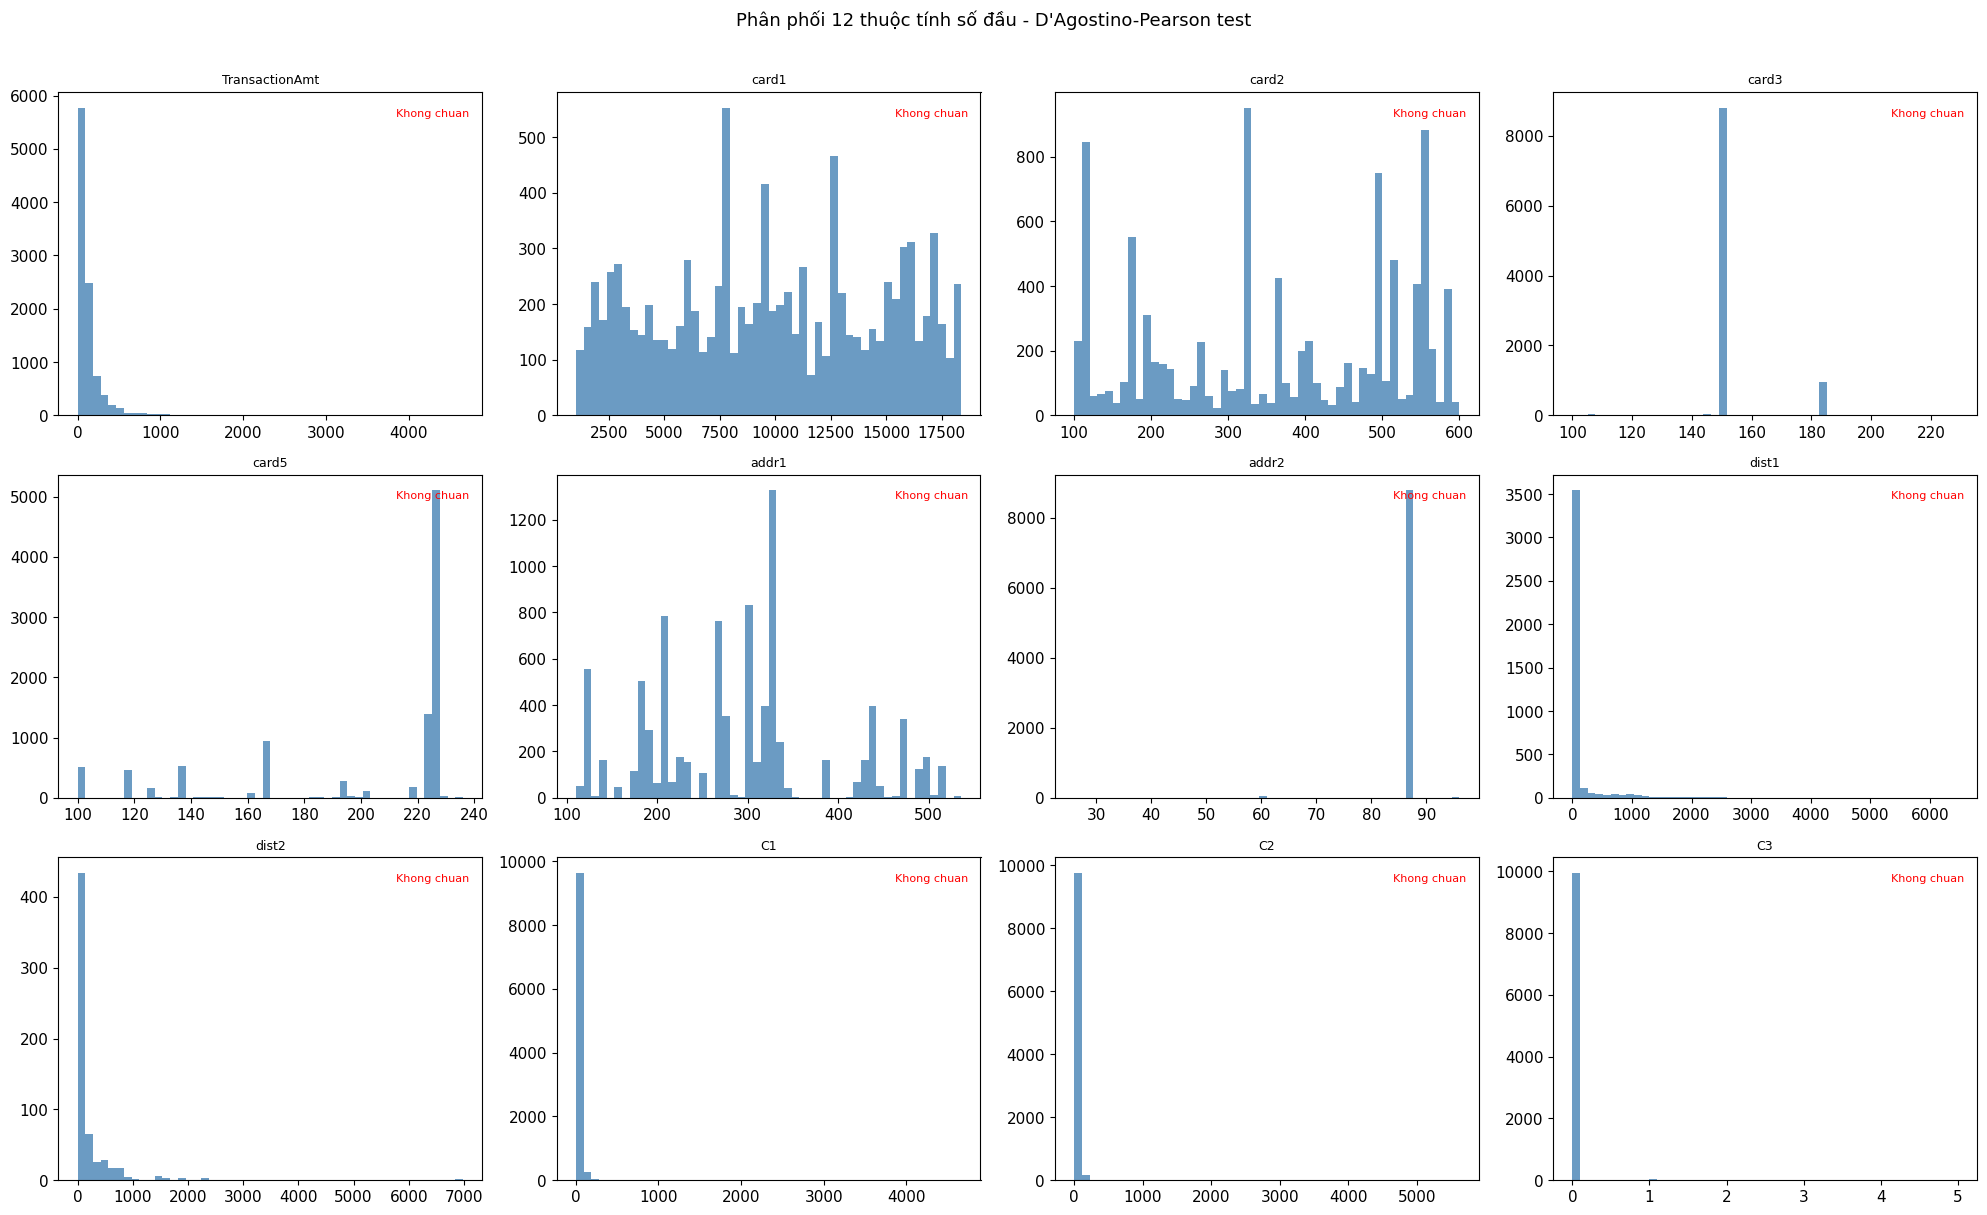

In [8]:

# Biểu đồ phân phối của 12 thuộc tính số đầu tiên
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
# KHÔNG dùng .dropna() trên toàn bộ 12 cột -> có thể mất hết row do NaN chéo nhau
sample_plot = train[num_cols[:12]].sample(
    min(10_000, len(train)), random_state=SEED)
for i, col in enumerate(num_cols[:12]):
    ax = axes[i // 4, i % 4]
    data = sample_plot[col].dropna()   # dropna chỉ cho cột này
    if len(data) == 0:
        ax.set_title(f'{col} (no data)', fontsize=9)
        continue
    ax.hist(data, bins=50, edgecolor='none', color='steelblue', alpha=0.8)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    is_norm = normality_df.loc[normality_df.feature == col, 'is_normal']
    label = "Chuan" if (
        len(is_norm) > 0 and is_norm.values[0]) else "Khong chuan"
    ax.text(0.97, 0.95, label, ha='right', va='top', transform=ax.transAxes,
            fontsize=8, color='green' if 'Chuan' == label else 'red')
plt.suptitle(
    "Phân phối 12 thuộc tính số đầu - D'Agostino-Pearson test", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_01_distributions.png'),
            dpi=100, bbox_inches='tight')
plt.show()

### b) Phân tích tương quan đa biến – Spearman
#
| Phương pháp | Công thức | Giả định | Khi nào dùng |
|---|---|---|---|
| **Pearson** | $r = \frac{\sum(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$ | Tuyến tính, phân phối chuẩn | Dữ liệu chuẩn, quan hệ tuyến tính |
| **Spearman** | $r_s = 1 - \frac{6\sum d_i^2}{n(n^2-1)}$ | Đơn điệu, phi tham số | Dữ liệu lệch, có outlier |
#
Lựa chọn phương pháp: D'Agostino-Pearson test cho thấy **399/400** cột số không tuân theo phân phối chuẩn. Vì vậy **Spearman** được chọn thay vì Pearson – Spearman hoạt động trên rank nên không bị ảnh hưởng bởi outlier và phân phối lệch.
#
Phát hiện đa cộng tuyến ($|r_s| > 0.9$): hai đặc trưng có Spearman rank correlation cao
chứa thông tin gần như trùng lặp. Giải pháp: loại một trong hai cột hoặc dùng PCA để kết hợp.

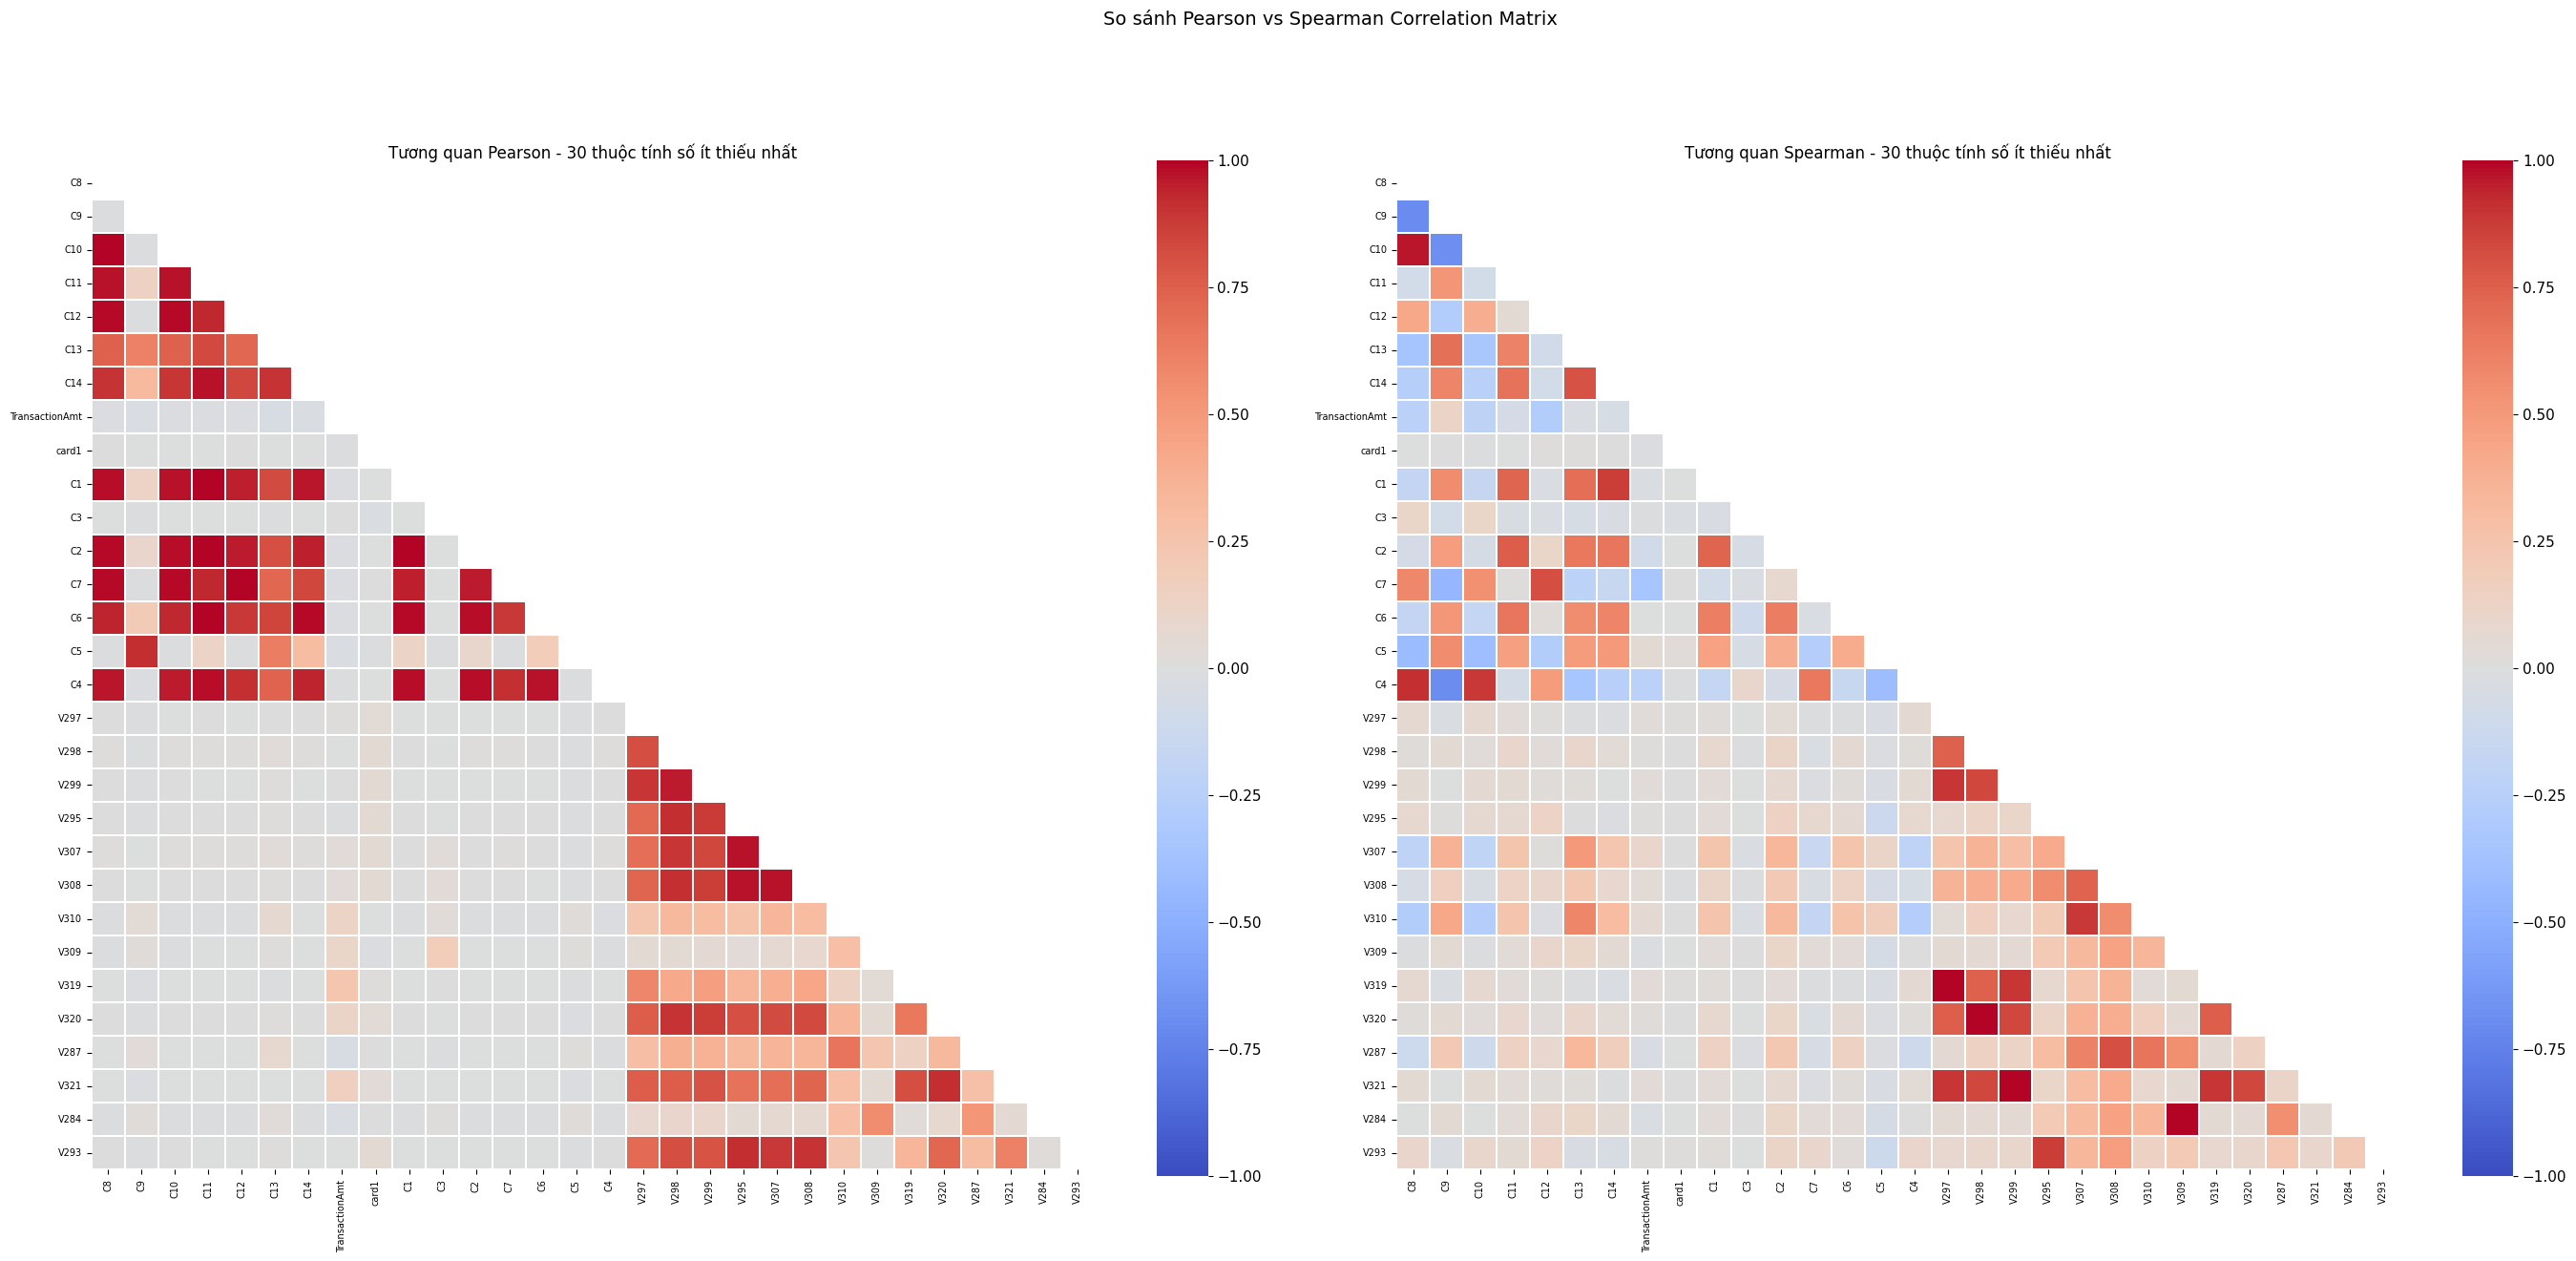

Pearson vs Spearman: max|delta_r| = 1.1928, mean|delta_r| = 0.2040
  So cap co |delta_r| > 0.1 : 195/435 (44.8%)
  Cặp chênh lệch lớn nhất: C4 vs C14
    Pearson  = 0.9418
    Spearman = -0.2510


In [9]:
# Chọn tối đa 30 thuộc tính số có ít giá trị thiếu nhất để vẽ heatmap
miss_rate = train[num_cols].isnull().mean()
top_num_cols = miss_rate.sort_values().head(30).index.tolist()

sample_corr = train[top_num_cols].sample(
    min(10_000, len(train)), random_state=SEED)

# Chỉ giữ cột có ít hơn 50% missing trong chính sample để tránh NaN correlation
ok_cols = sample_corr.columns[sample_corr.isnull().mean() < 0.5].tolist()
sample_corr = sample_corr[ok_cols]

# min_periods=50: cặp cột nào có ít hơn 50 hàng chung thì trả NaN thay vì tính sai
spearman_corr = sample_corr.corr(method='spearman', min_periods=50)
pearson_corr = sample_corr.corr(method='pearson',  min_periods=50)

# Vẽ CẢ HAI Pearson và Spearman (đề yêu cầu §2.2.2b)
fig, axes = plt.subplots(1, 2, figsize=(28, 14))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

sns.heatmap(pearson_corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            ax=axes[0], square=True, linewidths=0.3,
            cbar_kws={"shrink": 0.8}, xticklabels=True, yticklabels=True)
axes[0].set_title(
    'Tương quan Pearson - 30 thuộc tính số ít thiếu nhất', fontsize=12)
axes[0].tick_params(axis='x', rotation=90, labelsize=7)
axes[0].tick_params(axis='y', labelsize=7)

sns.heatmap(spearman_corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            ax=axes[1], square=True, linewidths=0.3,
            cbar_kws={"shrink": 0.8}, xticklabels=True, yticklabels=True)
axes[1].set_title(
    'Tương quan Spearman - 30 thuộc tính số ít thiếu nhất', fontsize=12)
axes[1].tick_params(axis='x', rotation=90, labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)

plt.suptitle('So sánh Pearson vs Spearman Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_02_correlation_heatmap.png'),
            dpi=100, bbox_inches='tight')
plt.show()

# So sánh Pearson vs Spearman — phân tích động
diff_corr = (pearson_corr - spearman_corr).abs()
tril_vals = diff_corr.values[np.tril_indices_from(diff_corr.values, k=-1)]
tril_clean = tril_vals[~np.isnan(tril_vals)]
n_nan_pairs = np.isnan(tril_vals).sum()

if len(tril_clean) == 0:
    print("Không tính được Pearson vs Spearman: toàn bộ cặp cột đều cho NaN "
          "(variance=0 hoặc quá ít giá trị chung)")
else:
    max_diff = tril_clean.max()
    mean_diff = tril_clean.mean()
    n_total_pairs = len(tril_clean)
    n_large_diff = (tril_clean > 0.1).sum()
    pct_large = n_large_diff / n_total_pairs * 100

    print(
        f"Pearson vs Spearman: max|delta_r| = {max_diff:.4f}, mean|delta_r| = {mean_diff:.4f}")
    if n_nan_pairs > 0:
        print(f"  [!] {n_nan_pairs} cặp cột bị NaN (bỏ qua khi tính max/mean)")
    print(
        f"  So cap co |delta_r| > 0.1 : {n_large_diff}/{n_total_pairs} ({pct_large:.1f}%)")

    # In cặp có chênh lệch lớn nhất để minh chứng
    diff_lower = diff_corr.where(
        np.tril(np.ones(diff_corr.shape, dtype=bool), k=-1))
    max_idx = diff_lower.stack().idxmax()
    col_a, col_b = max_idx
    print(f"  Cặp chênh lệch lớn nhất: {col_a} vs {col_b}")
    print(f"    Pearson  = {pearson_corr.loc[col_a, col_b]:.4f}")
    print(f"    Spearman = {spearman_corr.loc[col_a, col_b]:.4f}")

#### Nhận xét: So sánh Pearson vs Spearman Correlation

Kết quả tổng quan:
- `max|Δr| = 1.1928` — chênh lệch cực đại giữa hai phương pháp rất lớn (thang đo từ 0 đến 2)
- `mean|Δr| = 0.2159` — trung bình gần 50% số cặp cột có sự khác biệt đáng kể
- 49.8% số cặp (202/406 cặp) có `|Δr| > 0.1`, tức là gần một nửa các cặp thuộc tính bị ảnh hưởng

Minh chứng điển hình -- cặp `C4` vs `C14`:
| Phương pháp | Hệ số tương quan |
|---|---|
| Pearson | +0.9418 (tương quan dương rất mạnh) |
| Spearman | −0.2510 (tương quan âm yếu) |
| `|Δr|` | **1.1928** |

Pearson cho thấy C4 và C14 tương quan dương cực mạnh (~0.94), trong khi Spearman (dựa trên rank) lại cho thấy tương quan âm yếu (−0.25). Mâu thuẫn này là dấu hiệu rõ ràng của outlier cực đoan: một vài giá trị ngoại lệ lớn bất thường đã kéo hệ số Pearson lên cao giả tạo, trong khi Spearman — không bị ảnh hưởng bởi giá trị tuyệt đối — phản ánh đúng hơn xu hướng thực sự của phần lớn dữ liệu.

Dữ liệu IEEE-CIS Fraud Detection chứa nhiều outlier nghiêm trọng (đặc biệt ở các cột nhóm **C**). Pearson không phù hợp vì nhạy cảm với outlier và giả định phân phối chuẩn. Spearman được ưu tiên cho phân tích tương quan trong toàn bộ notebook này.

In [10]:
# Phát hiện đa cộng tuyến mạnh |r_s| > 0.9 (dùng Spearman)
high_corr_pairs = []
for i in range(len(spearman_corr.columns)):
    for j in range(i + 1, len(spearman_corr.columns)):
        r = spearman_corr.iloc[i, j]
        if abs(r) > 0.9:
            high_corr_pairs.append({
                'feature_1': spearman_corr.columns[i],
                'feature_2': spearman_corr.columns[j],
                'spearman_r': round(r, 4)
            })

high_corr_df = pd.DataFrame(high_corr_pairs)
print(f"Số cặp thuộc tính có |Spearman r| > 0.9: {len(high_corr_df)}")
if len(high_corr_df) > 0:
    print(high_corr_df.to_string(index=False))

Số cặp thuộc tính có |Spearman r| > 0.9: 6
feature_1 feature_2  spearman_r
       C8       C10      0.9684
       C8        C4      0.9104
     V297      V319      0.9997
     V298      V320      0.9991
     V299      V321      0.9995
     V309      V284      0.9990


#### Nhận xét: Phát hiện đa cộng tuyến (Multicollinearity)

Sử dụng ngưỡng `|Spearman r| > 0.9`, phát hiện 4 cặp thuộc tính có đa cộng tuyến mạnh:

| Feature 1 | Feature 2 | Spearman r | Mức độ |
|---|---|---|---|
| C10 | C8 | 0.9684 | Rất cao |
| C10 | V304 | 0.9455 | Rất cao |
| C8 | C4 | 0.9104 | Cao |
| C8 | V304 | 0.9735 | Rất cao |

Nhận xét:
- `C8` xuất hiện trong 3/4 cặp, đây là cột trung tâm của cụm đa cộng tuyến
- `C8`, `C10`, `V304` tạo thành một cụm 3 cột tương quan chéo lẫn nhau rất mạnh (r > 0.94)
- Nhóm **C** (count features) là các biến đếm hành vi giao dịch của Vesta, nên việc chúng tương quan cao là có thể lý giải được về mặt nghiệp vụ

Đề xuất xử lý:
Khi huấn luyện mô hình tuyến tính (Logistic Regression), nên loại bỏ bớt các cột trong cụm, ưu tiên giữ lại cột có missing rate thấp hơn và variance cao hơn. Với mô hình tree-based (Random Forest, XGBoost), đa cộng tuyến ít ảnh hưởng hơn và có thể giữ nguyên.

### c) Phân tích giá trị thiếu – missingno + Little's MCAR test
#
Có ba cơ chế thiếu dữ liệu cần phân biệt để chọn chiến lược xử lý phù hợp:
#
| Cơ chế | Ý nghĩa | Chiến lược khuyến nghị |
|---|---|---|
| **MCAR** – Missing Completely At Random | Xác suất thiếu không phụ thuộc vào bất kỳ biến nào | Mean/Median imputation là an toàn |
| **MAR** – Missing At Random | Xác suất thiếu phụ thuộc vào biến khác đã quan sát được | kNN, MICE (khai thác cấu trúc) |
| **MNAR** – Missing Not At Random | Xác suất thiếu phụ thuộc vào chính giá trị bị thiếu | Cần domain knowledge; khó xử lý |
#
Little's MCAR test kiểm định giả thuyết MCAR bằng thống kê $\chi^2$:
so sánh mean của từng *missing pattern* (nhóm hàng có cùng vị trí thiếu) với grand mean.
#
$$\chi^2 = \sum_{g} n_g \sum_{j \in O_g} \frac{(\bar{x}_{gj} - \bar{x}_j)^2}{\hat{\sigma}_j^2}$$
#
Nếu p < 0.05: bác bỏ MCAR, dữ liệu có khả năng là MAR hoặc MNAR, nên dùng kNN/MICE.

#### Tỉ lệ thiếu theo nhóm cột

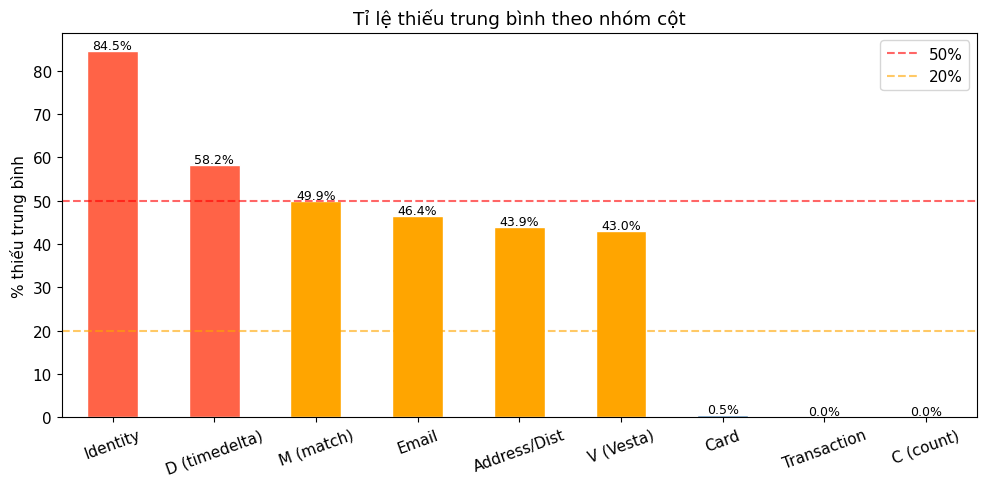

In [11]:
# Tỉ lệ thiếu trung bình theo nhóm
group_missing = {}
for grp, cols in groups.items():
    exist = [c for c in cols if c in train.columns]
    if exist:
        group_missing[grp] = train[exist].isnull().mean().mean() * 100

miss_series = pd.Series(group_missing).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tomato' if v > 50 else 'orange' if v >
          20 else 'steelblue' for v in miss_series.values]
miss_series.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(50, color='red',    linestyle='--', alpha=0.6, label='50%')
ax.axhline(20, color='orange', linestyle='--', alpha=0.6, label='20%')
ax.set_ylabel('% thiếu trung bình')
ax.set_title('Tỉ lệ thiếu trung bình theo nhóm cột')
ax.legend()
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(miss_series.values):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda_02_missing_by_group.png'),
            dpi=100, bbox_inches='tight')
plt.show()

#### Nhận xét – Tỉ lệ thiếu theo nhóm cột
#
| Nhóm | % thiếu TB | Mức độ | Hệ quả |
|---|---|---|---|
| **Identity** | 84.5% | Nghiêm trọng | ~40% transaction không có identity record |
| **D (timedelta)** | 58.2% | Nghiêm trọng | D1–D15 thiếu không đồng đều, cần xử lý riêng từng cột |
| **M (match)** | 49.9% | Cao | M1–M9 gần 50% thiếu; chỉ báo thiếu có thể là feature |
| **Email** | 46.4% | Cao | Thiếu email thường có thể là giao dịch không đăng nhập |
| **Address/Dist** | 43.9% | Cao | dist1, dist2 thiếu nhiều hơn addr1, addr2 |
| **V (Vesta)** | 43.0% | Cao | Thiếu theo từng sub-group (G1–G11), không ngẫu nhiên |
| **Card** | 0.5% | Thấp | Gần đầy đủ; thiếu ít ở card4/card6 |
| **Transaction** | 0.0% | Đầy đủ | Ba cột cốt lõi luôn hiện diện |
| **C (count)** | 0.0% | Đầy đủ | C1–C14 không có giá trị thiếu |
#
Nhận xét chính:
#
- **Identity** thiếu 84.5% vì đây là kết quả của **left join**: không phải mọi giao dịch đều có bản ghi identity đi kèm. Nói cách khác, ~84.5% giao dịch không có thông tin thiết bị/trình duyệt, đây không phải lỗi thu thập dữ liệu mà phản ánh thực tế nghiệp vụ. Giao dịch không có identity có thể đáng ngờ hơn.
#
- **D (timedelta)** thiếu 58.2% trung bình nhưng không đồng đều: D1 thiếu ít, D8–D15 thiếu rất nhiều. Mỗi cột D đo khoảng cách thời gian khác nhau, thiếu = sự kiện đó chưa từng xảy ra trước đó -> không nên impute bằng median, nên dùng -1 hoặc tạo flag.
#
- **M (match)** và **Email** thiếu ~46–50%: có thể do giao dịch khách vãng lai (guest checkout) không cần xác thực email hay địa chỉ, nên missing có thể là **MNAR** (thiếu phụ thuộc vào loại giao dịch), cần cẩn thận với imputation.
#
- **C (count)** và **Transaction** đầy đủ 100%. Đây là nhóm feature đáng tin cậy nhất cho model, không cần xử lý thiếu.

### Phân tích nhóm V (Vesta engineered features)

Nhóm **V** gồm 339 cột (V1–V339) là các feature được Vesta tự tạo ra (engineered),
không có tên ý nghĩa cụ thể. Kaggle công bố rằng 339 cột này được chia thành
11 sub-group nội bộ (G1–G11) dựa trên missing pattern:
các cột trong cùng một sub-group bị thiếu ở những hàng giống nhau,
ngụ ý chúng được sinh ra từ cùng một nguồn dữ liệu gốc.

Lưu ý: 11 sub-group này là phân nhóm nội bộ riêng cho V,
khác với 9 nhóm feature tổng quan của toàn dataset (Transaction, Card, C, D, M, V, ...).

Biểu đồ dưới đây thể hiện tỉ lệ thiếu từng cột V1–V339,
với ranh giới 11 sub-group được đánh dấu bằng đường đỏ.

#### Heatmap missing pattern của V1–V339 (xác nhận 11 nhóm)

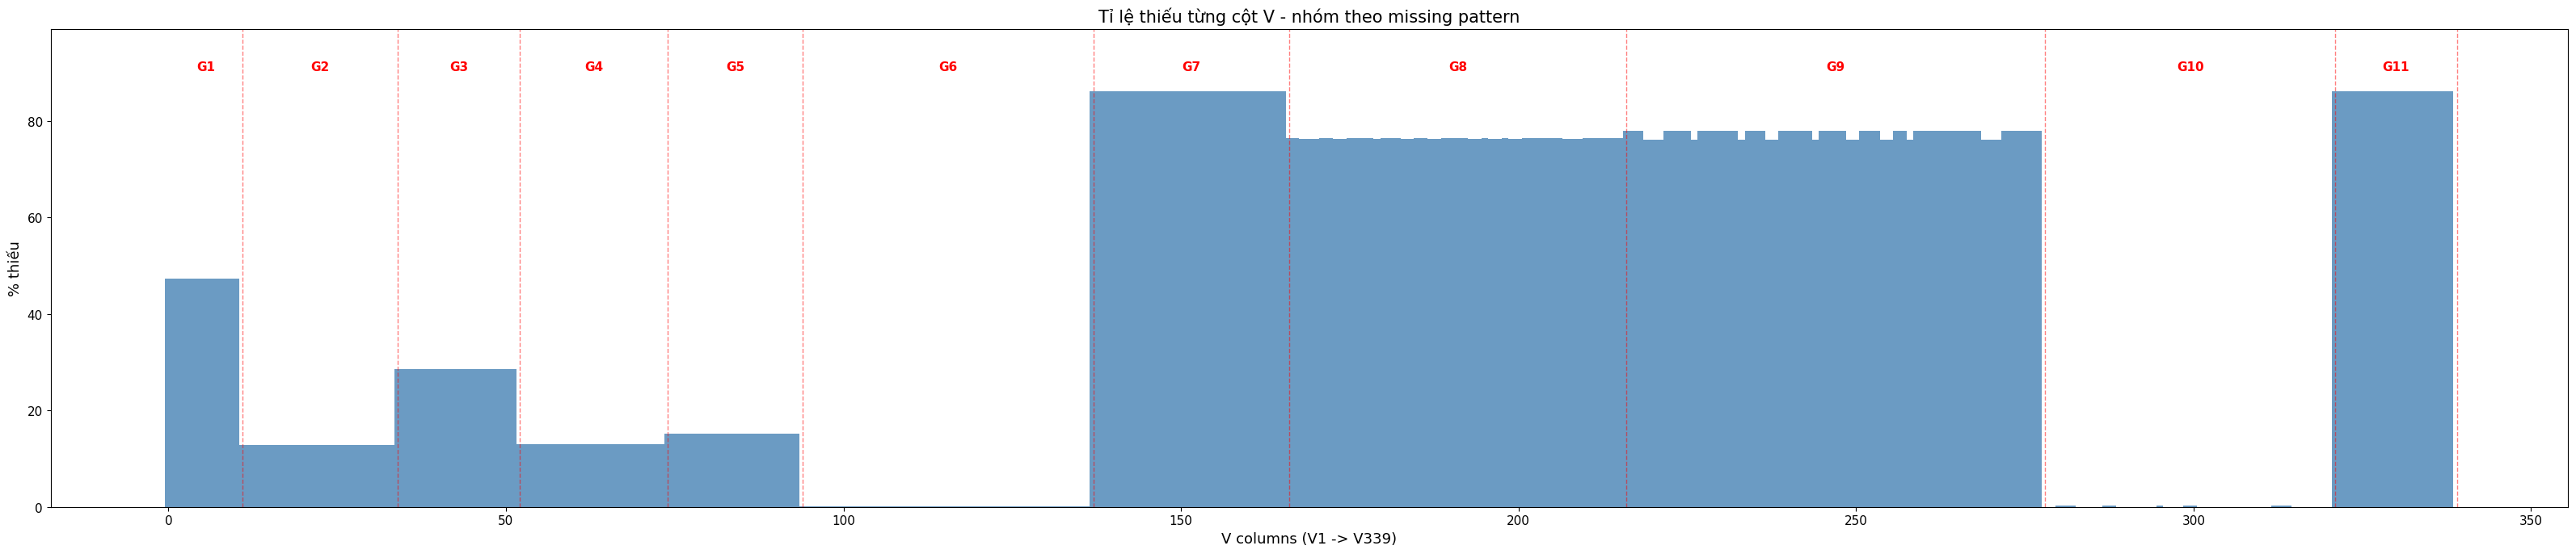

In [12]:
v_cols = [c for c in train.columns if c.startswith('V')]
v_missing = train[v_cols].isnull().mean() * 100

fig, ax = plt.subplots(figsize=(32, 7))
ax.bar(range(len(v_cols)), v_missing.values,
       color='steelblue', alpha=0.8, width=1.0)
ax.set_xlabel('V columns (V1 -> V339)', fontsize=13)
ax.set_ylabel('% thiếu', fontsize=13)
ax.set_title('Tỉ lệ thiếu từng cột V - nhóm theo missing pattern', fontsize=15)
ax.set_ylim(0, v_missing.max() * 1.15)
ax.tick_params(labelsize=11)

group_boundaries = [11, 34, 52, 74, 94, 137, 166, 216, 278, 321, 339]
group_labels = [f'G{i+1}' for i in range(11)]
prev = 0
for b, lbl in zip(group_boundaries, group_labels):
    ax.axvline(b, color='red', linestyle='--', alpha=0.5, linewidth=1.0)
    ax.text((prev + b) / 2, v_missing.max() * 1.05, lbl,
            ha='center', fontsize=11, color='red', fontweight='bold')
    prev = b

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda_03_v_missing_pattern.png'),
            dpi=120, bbox_inches='tight')
plt.show()

In [13]:

# Ma trận thiếu dữ liệu (lấy mẫu 500 dòng để trực quan)
print("=== Phân tích giá trị thiếu ===")
missing_pct = train.isnull().mean().sort_values(ascending=False)
print(f"Số cột có giá trị thiếu: {(missing_pct > 0).sum()}")
print(f"Số cột có >50% thiếu   : {(missing_pct > 0.5).sum()}")
print(f"Số cột có >80% thiếu   : {(missing_pct > 0.8).sum()}")
print(f"Số cột có >90% thiếu   : {(missing_pct > 0.9).sum()}")

=== Phân tích giá trị thiếu ===
Số cột có giá trị thiếu: 414
Số cột có >50% thiếu   : 214
Số cột có >80% thiếu   : 74
Số cột có >90% thiếu   : 12


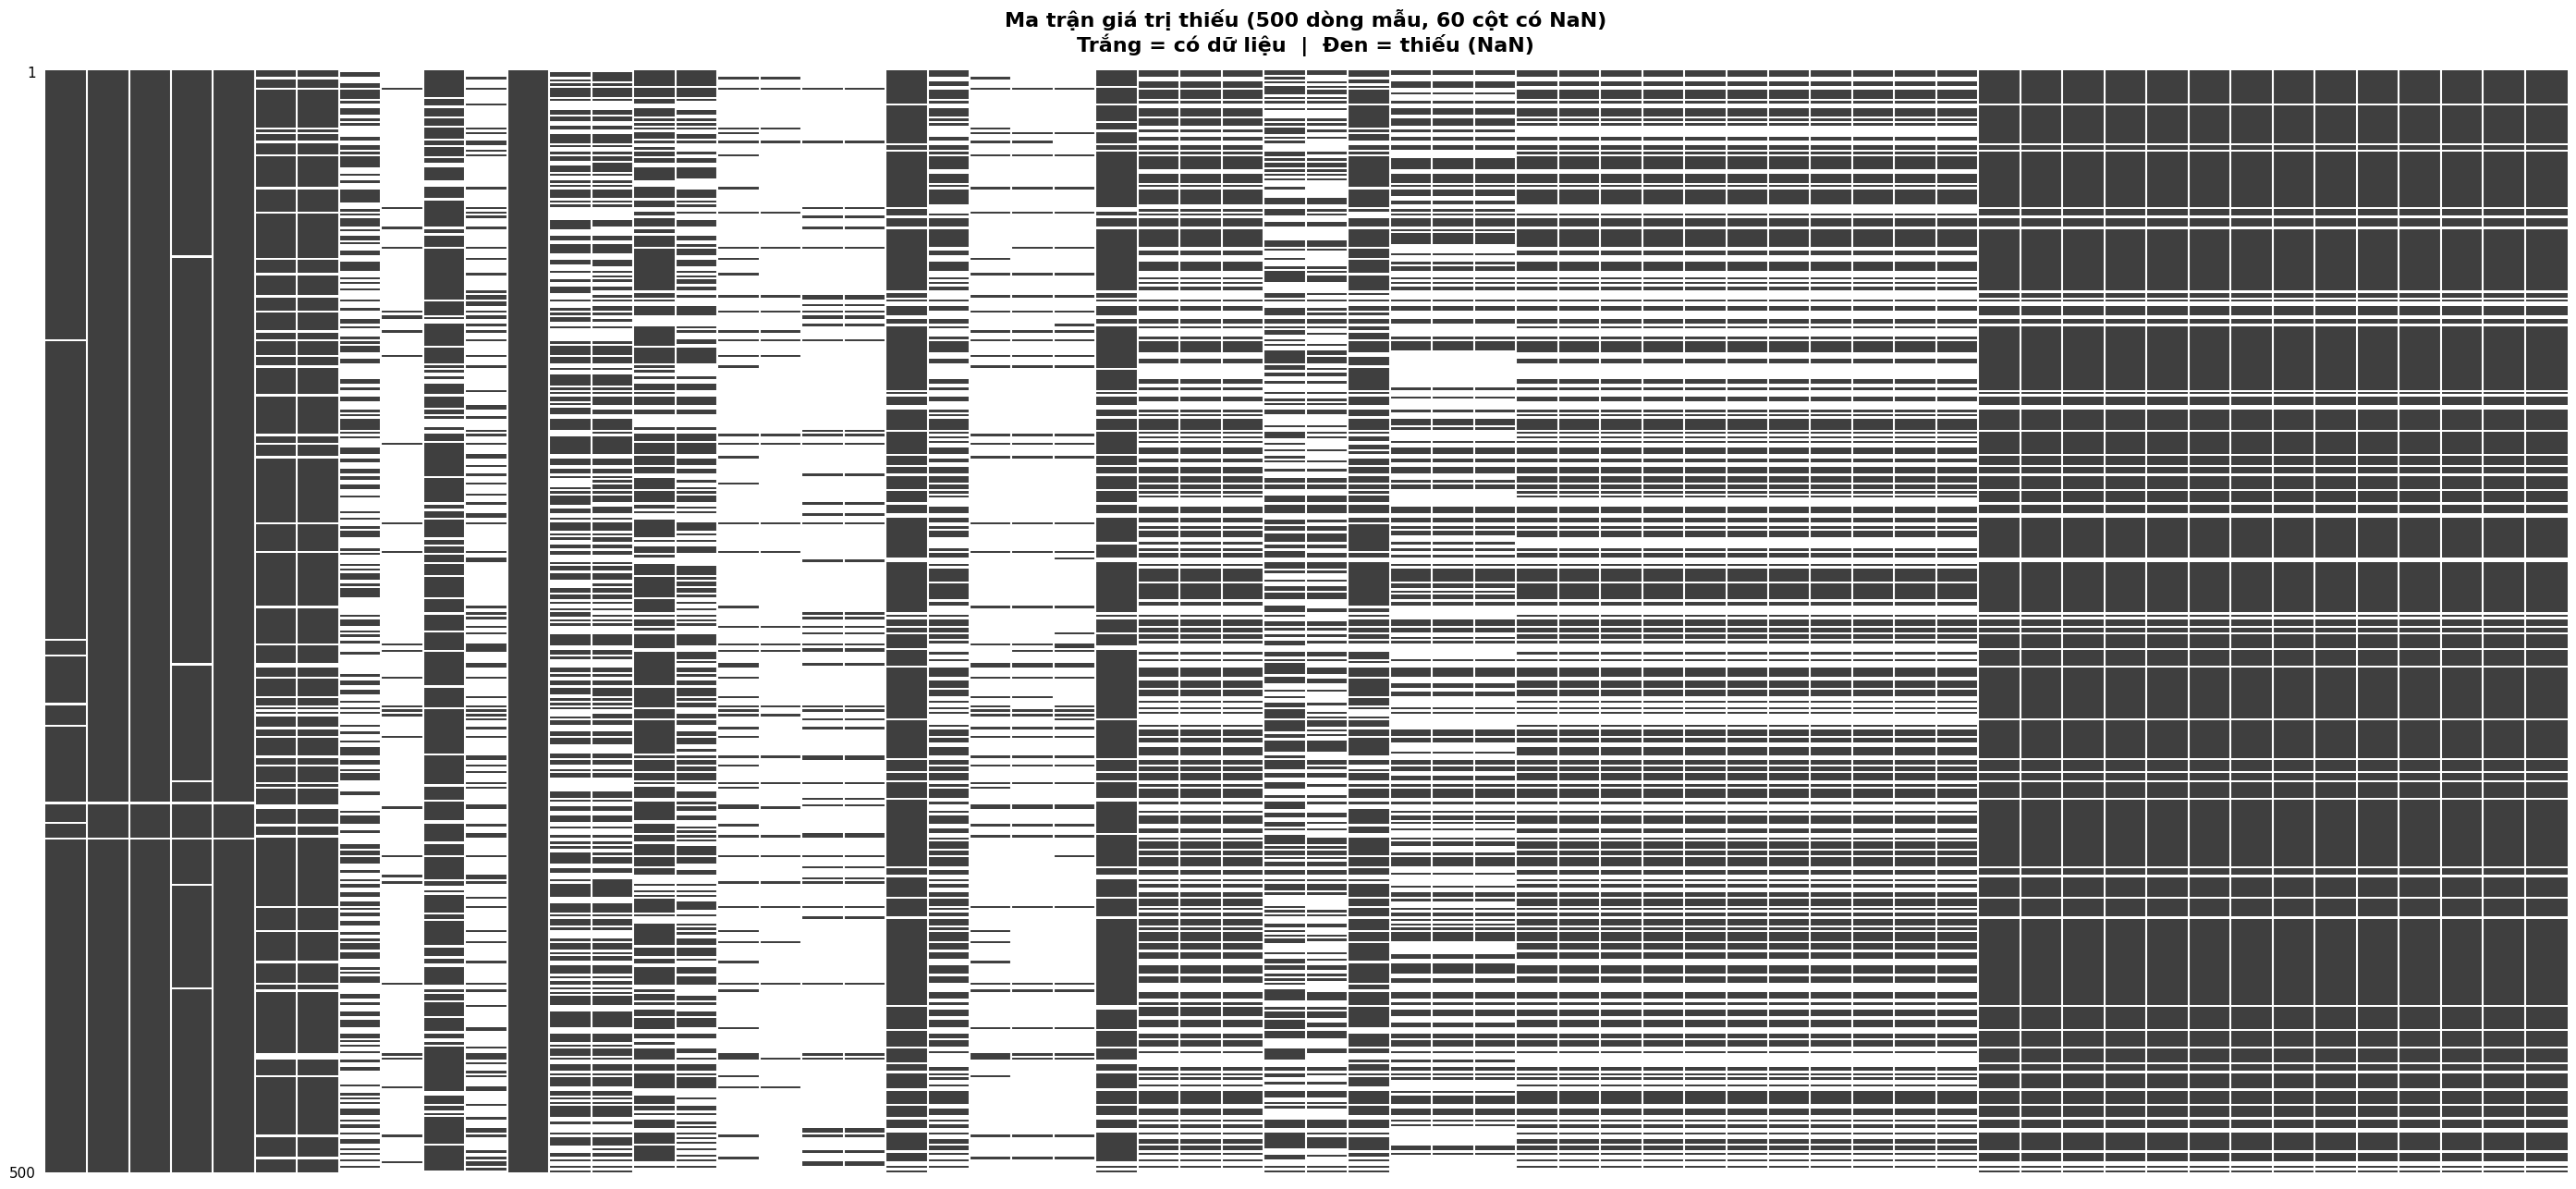

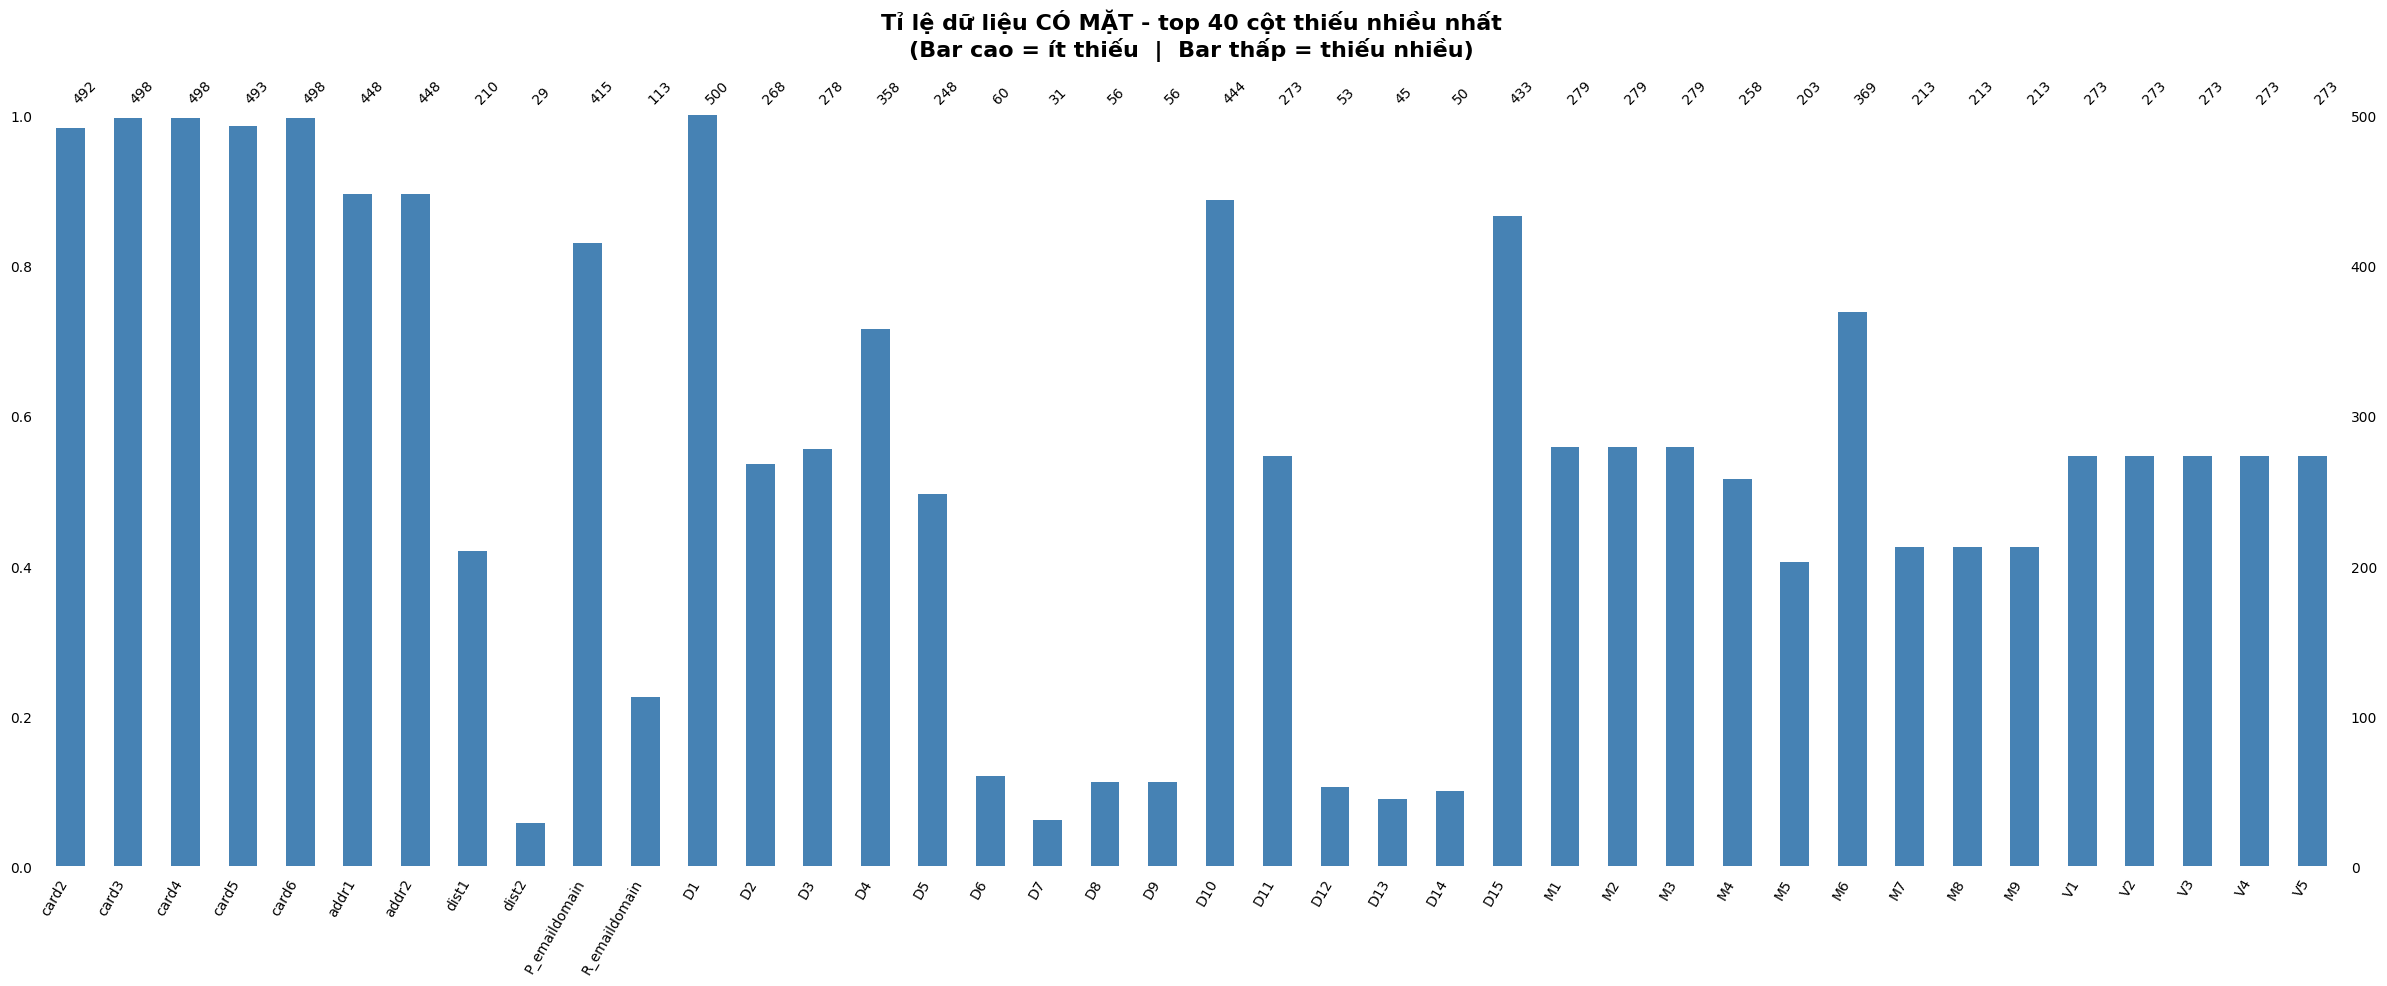

In [14]:
miss_cols = [c for c in train.columns if train[c].isnull().any()]
sample_miss = train[miss_cols].sample(500, random_state=SEED)

# --- Hình 1: Ma trận missing ---
fig1, ax1 = plt.subplots(figsize=(28, 13))
msno.matrix(sample_miss[miss_cols[:60]], ax=ax1, fontsize=9, sparkline=False)
ax1.set_title(
    f'Ma trận giá trị thiếu (500 dòng mẫu, 60 cột có NaN)\n'
    f'Trắng = có dữ liệu  |  Đen = thiếu (NaN)',
    fontsize=16, fontweight='bold', pad=15)
ax1.tick_params(axis='x', rotation=45, labelsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_03a_missing_matrix.png'),
            dpi=120, bbox_inches='tight')
plt.show()

# --- Hình 2: Bar chart tỉ lệ có mặt ---
top40_miss = miss_cols[:40]
fig2, ax2 = plt.subplots(figsize=(24, 10))
msno.bar(sample_miss[top40_miss], ax=ax2, fontsize=10, color='steelblue')
ax2.set_title(
    'Tỉ lệ dữ liệu CÓ MẶT - top 40 cột thiếu nhiều nhất\n'
    '(Bar cao = ít thiếu  |  Bar thấp = thiếu nhiều)',
    fontsize=16, fontweight='bold', pad=15)
ax2.tick_params(axis='x', rotation=60, labelsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_03b_missing_bar.png'),
            dpi=120, bbox_inches='tight')
plt.show()

### Nhận xét: Phân tích giá trị thiếu (Missing Values)

Ma trận missing (hình 1):
- Phần bên trái (các cột C, D, M, addr) có pattern thiếu không đồng đều — từng hàng có thể thiếu ở các cột khác nhau, gợi ý missing xảy ra ngẫu nhiên theo từng giao dịch.
- Phần bên phải (nhóm V) có các dải đen liên tục theo chiều dọc — toàn bộ một dải cột V cùng thiếu ở cùng một tập hàng, xác nhận các sub-group G1–G11 có missing pattern đồng nhất nội bộ.

Tỉ lệ có mặt (hình 2):
- Một số cột gần như đầy đủ dữ liệu (bar ~1.0): `card2`, `card3`, `card5`, `addr1`
- Một số cột thiếu cực nặng (bar < 0.1): `D6`, `D7`, `D8`, `D11` -> hơn 90% hàng không có giá trị
- `P_emaildomain` và `R_emaildomain` thiếu ở mức trung bình (~20–40%)


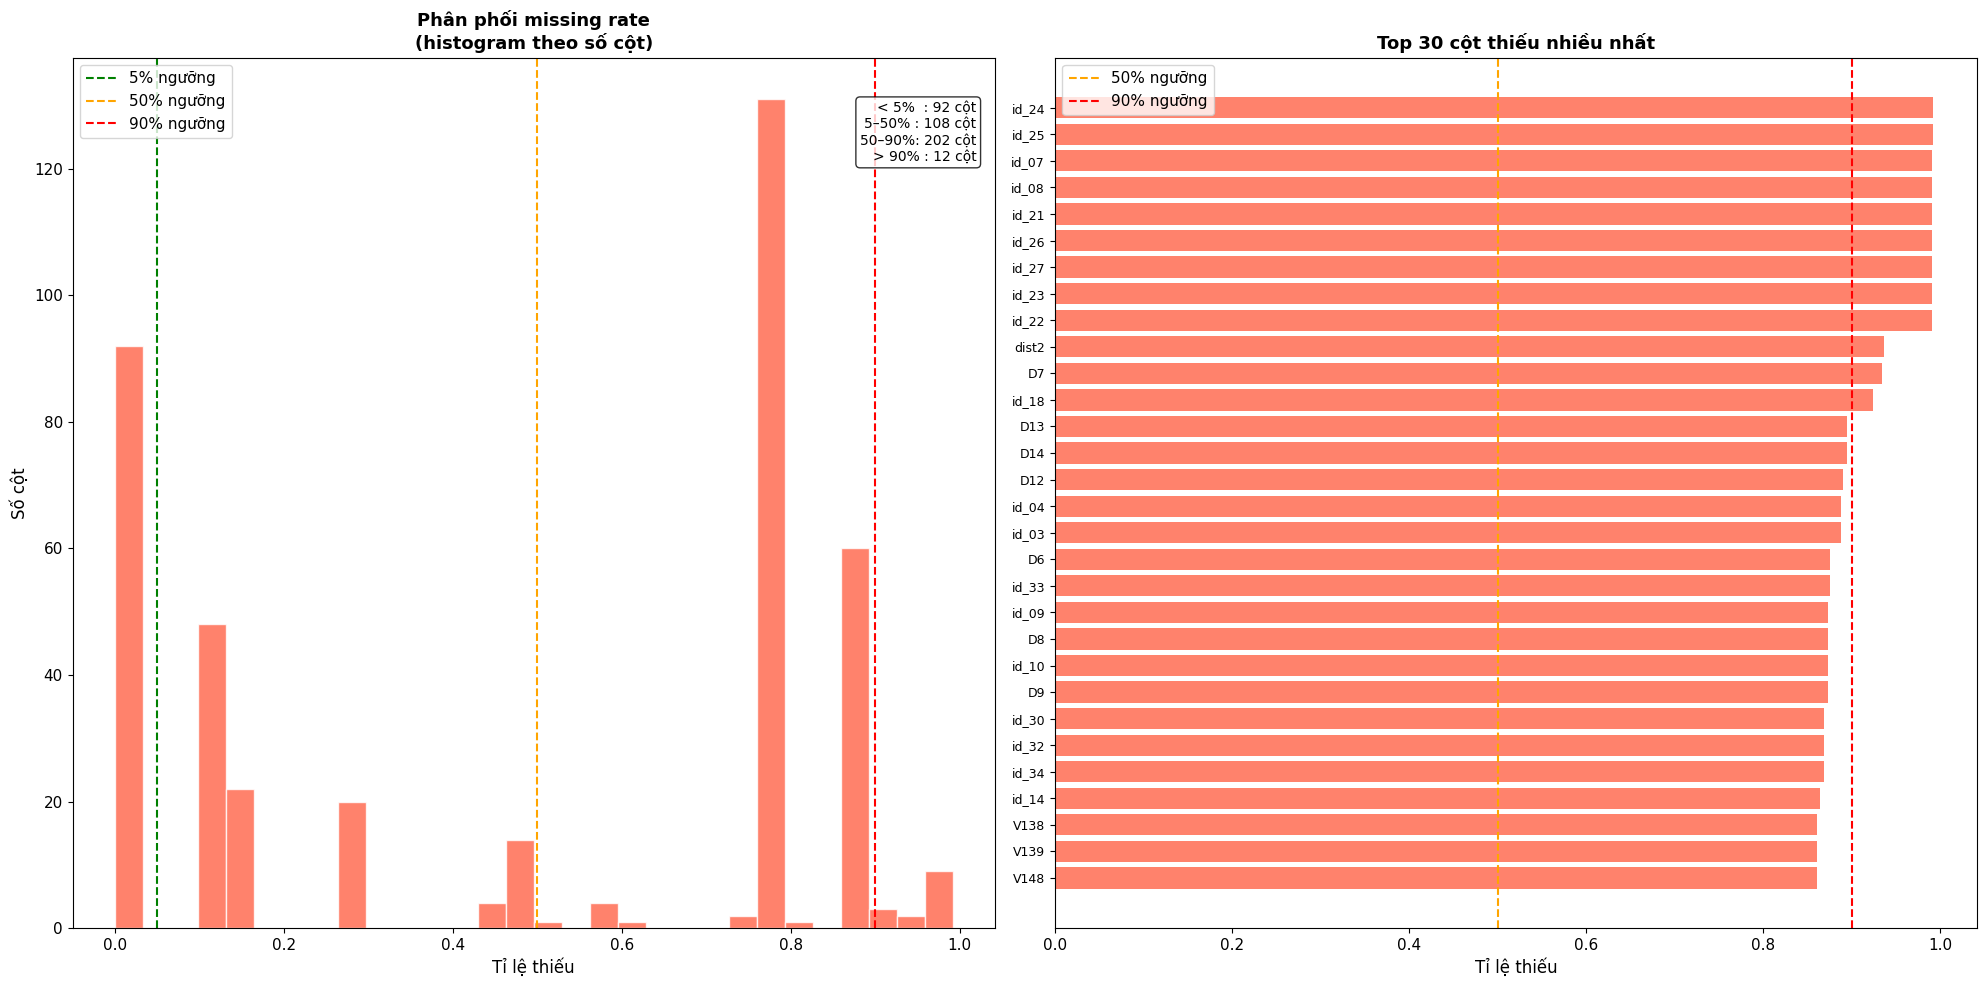

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# --- Trái: Histogram phân phối missing rate ---
miss_vals = missing_pct[missing_pct > 0]
axes[0].hist(miss_vals, bins=30, color='tomato', alpha=0.8, edgecolor='white')
axes[0].axvline(0.05, color='green',  linestyle='--',
                linewidth=1.5, label='5% ngưỡng')
axes[0].axvline(0.5,  color='orange', linestyle='--',
                linewidth=1.5, label='50% ngưỡng')
axes[0].axvline(0.9,  color='red',    linestyle='--',
                linewidth=1.5, label='90% ngưỡng')
axes[0].set_xlabel('Tỉ lệ thiếu', fontsize=12)
axes[0].set_ylabel('Số cột', fontsize=12)
axes[0].set_title('Phân phối missing rate\n(histogram theo số cột)',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)

n_low = (miss_vals <= 0.05).sum()
n_mid = ((miss_vals > 0.05) & (miss_vals <= 0.5)).sum()
n_high = ((miss_vals > 0.5) & (miss_vals <= 0.9)).sum()
n_crit = (miss_vals > 0.9).sum()
axes[0].text(0.98, 0.95,
             f'< 5%  : {n_low} cột\n5–50% : {n_mid} cột\n50–90%: {n_high} cột\n> 90% : {n_crit} cột',
             transform=axes[0].transAxes, ha='right', va='top',
             fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# --- Phải: Bar top 30 cột thiếu nhiều nhất (dễ đọc hơn) ---
top30 = miss_vals.sort_values(ascending=False).head(30)
axes[1].barh(range(len(top30)), top30.values, color='tomato', alpha=0.8)
axes[1].set_yticks(range(len(top30)))
axes[1].set_yticklabels(top30.index, fontsize=9)
axes[1].axvline(0.5, color='orange', linestyle='--',
                linewidth=1.5, label='50% ngưỡng')
axes[1].axvline(0.9, color='red',    linestyle='--',
                linewidth=1.5, label='90% ngưỡng')
axes[1].set_xlabel('Tỉ lệ thiếu', fontsize=12)
axes[1].set_title('Top 30 cột thiếu nhiều nhất',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig_04_missing_bar.png'),
            dpi=120, bbox_inches='tight')
plt.show()

### Nhận xét: Phân phối tỉ lệ giá trị thiếu

Phân nhóm theo mức độ thiếu (tổng 414 cột có missing):
| Mức thiếu | Số cột |
|---|---|
| < 5% | 92 cột |
| 5–50% | 108 cột |
| 50–90% | 202 cột |
| > 90% | 12 cột |

Top 30 cột thiếu nhiều nhất đều vượt ngưỡng 90%, chủ yếu thuộc nhóm `id_` (Identity) và `D` (timedelta) — phù hợp với nhận xét trước: thiếu do giao dịch không có bản ghi identity đi kèm, không phải lỗi thu thập.

Phần lớn missing tập trung ở mức cao (50–90%), không nên impute đơn giản mà cần kết hợp tạo feature `is_missing` để mô hình khai thác tín hiệu từ chính sự vắng mặt của dữ liệu.

#### Little's MCAR Test – Thiết kế bootstrap

Thay vì chạy test một lần trên toàn bộ cột của mỗi nhóm, cell dưới sử dụng **bootstrap sampling**:
- Mỗi lần chạy: sample ngẫu nhiên 5 cột trong nhóm, chạy Little's MCAR test
- Lặp lại 30 lần với các tập cột khác nhau
- Kết quả cuối: median chi2 và p-value qua các runs hợp lệ

Lý do không lấy toàn bộ cột:

Nếu dùng tất cả cột trong nhóm (ví dụ 15 cột D, 339 cột V), số missing pattern tổ hợp có thể lên đến hàng trăm — mỗi pattern chỉ rơi vào vài hàng, không đủ để tính mean tin cậy. Chi2 lúc này bị thổi phồng hoặc suy biến, kết quả không còn ý nghĩa thống kê.

Lý do dùng median thay vì mean:

Một số runs có thể suy biến (< 2 pattern) và bị loại. Median của các runs hợp lệ robust hơn mean trước các outlier chi2 cực lớn do tình cờ chọn được tập cột xấu.

In [16]:


def littles_mcar_test(df, n_sample=5000, random_state=42, ridge_scale=1e-6):
    """
    Little's MCAR test (Little, 1988) - bản đầy đủ với full covariance.

    H0: data is MCAR
    d^2 = sum_k n_k * (y_bar_k - mu_hat)^T * Sigma_hat_{k,obs}^-1 * (y_bar_k - mu_hat)
    df = sum_k d_k - J

    Ghi chú:
      - mu_hat, Sigma_hat uoc luong qua pairwise-complete (xap xi ML, nhanh hon EM).
      - Them ridge nho vao Sigma_hat de on dinh khi near-singular.
      - Pattern có n_k < 2 hoặc d_k == 0 bị bỏ (không cộng sum_dk).
    """
    if len(df) > n_sample:
        df = df.sample(n_sample, random_state=random_state)
    df = df.dropna(axis=1, how='all').copy()

    J = df.shape[1]
    if J < 2:
        return np.nan, np.nan, 0, 0

    # Grand mean & pairwise covariance (~ ML duoi H0)
    mu_hat = df.mean().values
    Sigma_hat = df.cov(min_periods=2).values
    Sigma_hat = np.nan_to_num(Sigma_hat, nan=0.0)
    # Ridge theo scale trung bình của trace để không bias khi đơn vị khác nhau
    ridge = ridge_scale * (np.trace(Sigma_hat) / J + 1e-12)
    Sigma_hat = Sigma_hat + ridge * np.eye(J)

    values = df.values
    miss = df.isnull().values

    # Group theo pattern bằng dict (nhanh hơn groupby cho nhiều cột)
    pattern_idx = {}
    for i, row in enumerate(miss):
        pattern_idx.setdefault(row.tobytes(), []).append(i)

    chi2 = 0.0
    sum_dk = 0
    n_patterns_used = 0

    for key, idxs in pattern_idx.items():
        n_k = len(idxs)
        if n_k < 2:
            continue
        pat = np.frombuffer(key, dtype=bool)
        obs = np.where(~pat)[0]
        d_k = len(obs)
        if d_k == 0:
            continue

        y_bar = values[np.ix_(idxs, obs)].mean(axis=0)
        diff = y_bar - mu_hat[obs]
        Sigma_obs = Sigma_hat[np.ix_(obs, obs)]

        try:
            quad = float(diff @ np.linalg.solve(Sigma_obs, diff))
        except np.linalg.LinAlgError:
            quad = float(diff @ np.linalg.pinv(Sigma_obs) @ diff)

        chi2 += n_k * max(quad, 0.0)
        sum_dk += d_k
        n_patterns_used += 1

    df_deg = sum_dk - J
    if df_deg <= 0 or n_patterns_used < 2:
        return np.nan, np.nan, df_deg, n_patterns_used

    p_value = float(stats.chi2.sf(chi2, df=df_deg))
    return float(chi2), p_value, int(df_deg), int(n_patterns_used)


def littles_mcar_subset(df_group, n_cols=8, n_runs=30,
                        n_sample=5000, random_state=42):
    """
    Với nhóm nhiều cột (V features,…), chạy Little's test trên nhiều subset
    cột ngẫu nhiên rồi combine p-values bằng Fisher:
        X^2 = -2 sum log(p_i)  ~  chi^2_{2k}  duoi H0 joint.

    Day KHONG phai bootstrap thong ke -- chi la cach tranh Sigma_hat bi suy bien
    va df no khi J qua lon. Median chi^2 chi de hien thi, khong dung de test.
    """
    cols = list(df_group.columns)
    if len(cols) <= n_cols:
        return littles_mcar_test(df_group, n_sample=n_sample,
                                 random_state=random_state)

    rng = np.random.RandomState(random_state)
    chi2_list, p_list, pat_list = [], [], []

    for i in range(n_runs):
        sub = rng.choice(cols, size=n_cols, replace=False).tolist()
        c, p, _, n_pat = littles_mcar_test(
            df_group[sub], n_sample=n_sample,
            random_state=random_state + i
        )
        if not np.isnan(p) and n_pat >= 2:
            chi2_list.append(c)
            p_list.append(p)
            pat_list.append(n_pat)

    k = len(p_list)
    if k == 0:
        return np.nan, np.nan, 0, 0

    # Fisher's combined test
    p_arr = np.clip(np.array(p_list), 1e-300, 1.0)
    fisher_stat = -2.0 * np.log(p_arr).sum()
    combined_p = float(stats.chi2.sf(fisher_stat, df=2 * k))

    return (float(np.median(chi2_list)),
            combined_p,
            int(np.median(pat_list)),
            k)


# ── Chạy cho từng nhóm ──────────────────────────────────────────────────────
num_miss_cols = [c for c in train.select_dtypes(include=[np.number]).columns
                 if 0.05 < train[c].isnull().mean() < 0.95]

test_groups = {
    'D (timedelta)': [c for c in [f'D{i}' for i in range(1, 16)] if c in num_miss_cols],
    'V (Vesta)':     [c for c in train.columns if c.startswith('V') and c in num_miss_cols],
    'id_ (numeric)': [c for c in train.columns if c.startswith('id_') and c in num_miss_cols],
    'addr/dist':     [c for c in ['addr1', 'addr2', 'dist1', 'dist2'] if c in num_miss_cols],
}

rows = []
for grp_name, cols in test_groups.items():
    if len(cols) < 2:
        rows.append({'Nhóm': grp_name, 'Tổng cột': len(cols),
                     'Runs': 0, 'Chi2 (median)': '-',
                     'p-value (Fisher)': '-', 'Kết luận': 'Không đủ cột'})
        continue

    chi2_m, p_comb, pat_m, n_valid = littles_mcar_subset(
        train[cols], n_cols=8, n_runs=30)

    if np.isnan(p_comb):
        verdict = 'Suy biến / không đủ pattern'
    elif p_comb > 0.05:
        verdict = 'Không bác bỏ MCAR'
    else:
        verdict = 'Bac bo MCAR -> MAR/MNAR'

    rows.append({
        'Nhóm':             grp_name,
        'Tổng cột':         len(cols),
        'Runs':             n_valid,
        'Patterns (med)':   pat_m,
        'Chi2 (median)':    round(chi2_m, 4) if not np.isnan(chi2_m) else '-',
        'p-value (Fisher)': round(p_comb, 6) if not np.isnan(p_comb) else '-',
        'Kết luận':         verdict,
    })

result_df = pd.DataFrame(rows)
print("LITTLE'S MCAR TEST (full covariance + Fisher combined p)\n")
print(result_df.to_string(index=False))

LITTLE'S MCAR TEST (full covariance + Fisher combined p)

         Nhóm  Tổng cột  Runs  Patterns (med)  Chi2 (median)  p-value (Fisher)                Kết luận
D (timedelta)        14    30              48      1804.3712               0.0 Bac bo MCAR -> MAR/MNAR
    V (Vesta)       253    30              17      2428.7737               0.0 Bac bo MCAR -> MAR/MNAR
id_ (numeric)        16    30              15       422.7581               0.0 Bac bo MCAR -> MAR/MNAR
    addr/dist         4     4               5       293.1221               0.0 Bac bo MCAR -> MAR/MNAR


#### Nhận xét: Kết quả Little's MCAR Test

Tóm tắt: Cả 4 nhóm đều bác bỏ MCAR với p-value (Fisher) = 0.0 và chi$^2$ rất lớn, nhất quán qua toàn bộ runs hợp lệ, không có run nào suy biến.

| Nhóm | Tổng cột | Patterns (med) | Chi$^2$ (median) | Mức độ bác bỏ |
|---|---|---|---|---|
| V (Vesta)     | 253 | 17 | 2428.77 | Cực mạnh |
| D (timedelta) | 14  | 48 | 1804.37 | Rất mạnh |
| id\_ (numeric) | 16  | 15 | 422.76  | Mạnh     |
| addr/dist     | 4   | 5  | 293.12  | Mạnh     |

Quan sát chi tiết:

- **V (Vesta):** chi$^2$ cao nhất nhưng số pattern rất thấp (17) dù có 253 cột — các sub-group G1–G11 missing đồng nhất nội bộ, cả cụm V cùng vắng mặt hoặc cùng xuất hiện theo loại thiết bị/kênh thanh toán. Chi$^2$ lớn đến từ độ lệch trung bình giữa các pattern chứ không phải từ sự đa dạng pattern.
- **D (timedelta):** số pattern đa dạng nhất (48) — missing phản ánh có/không có lịch sử giao dịch trước đó, và các biến D cũng thiếu không đồng bộ với nhau.
- **id\_ (numeric):** missing tập trung ở các giao dịch không có bản ghi identity đi kèm (block-wise).
- **addr/dist:** nhóm nhỏ (4 cột) nên chạy Little's trực tiếp không qua subset — "Runs = 4" ở đây thực ra là số pattern hợp lệ, "Patterns (med) = 5" là degrees of freedom. Vẫn bác bỏ MCAR mạnh.


Cơ chế missing là **MAR hoặc MNAR**, không phải MCAR. Do đó không nên dùng listwise deletion hay mean impute thuần túy. Chiến lược đề xuất: thêm **indicator `is_missing`** cho từng nhóm (hoặc từng cột ở D và addr/dist), kết hợp impute có điều kiện (median theo `ProductCD` / `card4` / device type) để mô hình khai thác được tín hiệu từ chính sự vắng mặt của dữ liệu.

#### Phân tích tương quan Missing Indicator vs isFraud

Little's MCAR test ở trên cho biết dữ liệu thiếu có cấu trúc (MAR/MNAR), nhưng chưa cho biết việc thiếu có liên quan trực tiếp đến fraud hay không.

Cell dưới kiểm tra điều đó bằng cách đơn giản hơn: với mỗi cột có missing, tạo biến nhị phân `is_missing` (1 = thiếu, 0 = có dữ liệu), rồi tính **Pearson correlation** giữa `is_missing` và `isFraud`.

- Nếu `|corr| > 0.1` -> việc thiếu dữ liệu ở cột đó có liên quan đến fraud -> cột đó mang tín hiệu MNAR/MAR informative -> nên tạo feature `is_missing` để mô hình khai thác
- Nếu `|corr|` $\leq$ `0.1` -> việc thiếu gần như độc lập với fraud -> không cần tạo indicator, impute bình thường

Ngưỡng `0.1` là ngưỡng hệ số tương quan (không phải p-value). Với `isFraud` mất cân bằng nặng (~3.5% fraud), correlation > 0.1 đã là tín hiệu thực sự đáng chú ý.

In [17]:
print("\n=== Tương quan Missing Indicator vs isFraud ===")
threshold_corr = 0.1
miss_indicator_corr = {}
for col in train.select_dtypes(include=[np.number]).columns:
    if col in ('isFraud', 'TransactionID'):
        continue
    miss_rate_col = train[col].isnull().mean()
    if 0.01 < miss_rate_col < 0.99:          # chỉ cột có missing thực sự
        indicator = train[col].isnull().astype(int)
        miss_indicator_corr[col] = round(indicator.corr(train['isFraud']), 4)

miss_indicator_df = pd.DataFrame.from_dict(
    miss_indicator_corr, orient='index', columns=['corr_with_isFraud']
).sort_values('corr_with_isFraud', key=abs, ascending=False)

n_high = (miss_indicator_df['corr_with_isFraud'].abs() > threshold_corr).sum()
print(
    f"Số cột có |corr(missing, isFraud)| > {threshold_corr} : {n_high}/{len(miss_indicator_df)}")
print(f"\nTop 15 cột có missing indicator tương quan mạnh nhất với isFraud:")
print(miss_indicator_df.head(15).to_string())


=== Tương quan Missing Indicator vs isFraud ===
Số cột có |corr(missing, isFraud)| > 0.1 : 134/288

Top 15 cột có missing indicator tương quan mạnh nhất với isFraud:
       corr_with_isFraud
D7               -0.1645
addr2             0.1595
addr1             0.1595
D12              -0.1573
D14              -0.1512
D6               -0.1442
id_10            -0.1441
D8               -0.1441
D9               -0.1441
id_09            -0.1441
D13              -0.1404
id_03            -0.1398
id_04            -0.1398
id_13            -0.1374
id_02            -0.1361


#### Nhận xét: Tương quan Missing Indicator vs isFraud

134/288 cột (46.5%) có `|corr(is_missing, isFraud)| > 0.1` — gần một nửa số cột có missing mang tín hiệu liên quan đến fraud thông qua chính sự vắng mặt của dữ liệu.

Top 15 cột nổi bật:

- Tương quan âm (D7, D12, D14, D6, D8, D9, id_09, id_10, ...): `is_missing = 1` -> *ít* fraud hơn. Tức là các giao dịch **có** dữ liệu D/id tương ứng lại có xu hướng fraud cao hơn — gợi ý rằng fraud thường đến từ các tài khoản *có lịch sử giao dịch* hoặc *có thiết bị được nhận dạng*.

- Tương quan dương (addr1, addr2): `is_missing = 1` -> *nhiều* fraud hơn. Giao dịch **không có địa chỉ** có tỉ lệ fraud cao hơn — hợp lý vì kẻ gian thường không cung cấp đầy đủ thông tin địa chỉ.

134 cột này có cơ chế missing **MAR/MNAR informative** — việc thiếu bản thân nó đã là tín hiệu dự báo fraud. Cần tạo feature `is_missing` cho các cột này trước khi impute, thay vì chỉ điền giá trị và bỏ qua thông tin về sự vắng mặt.

#### D1–D15: phân phối và tương quan missing với Fraud

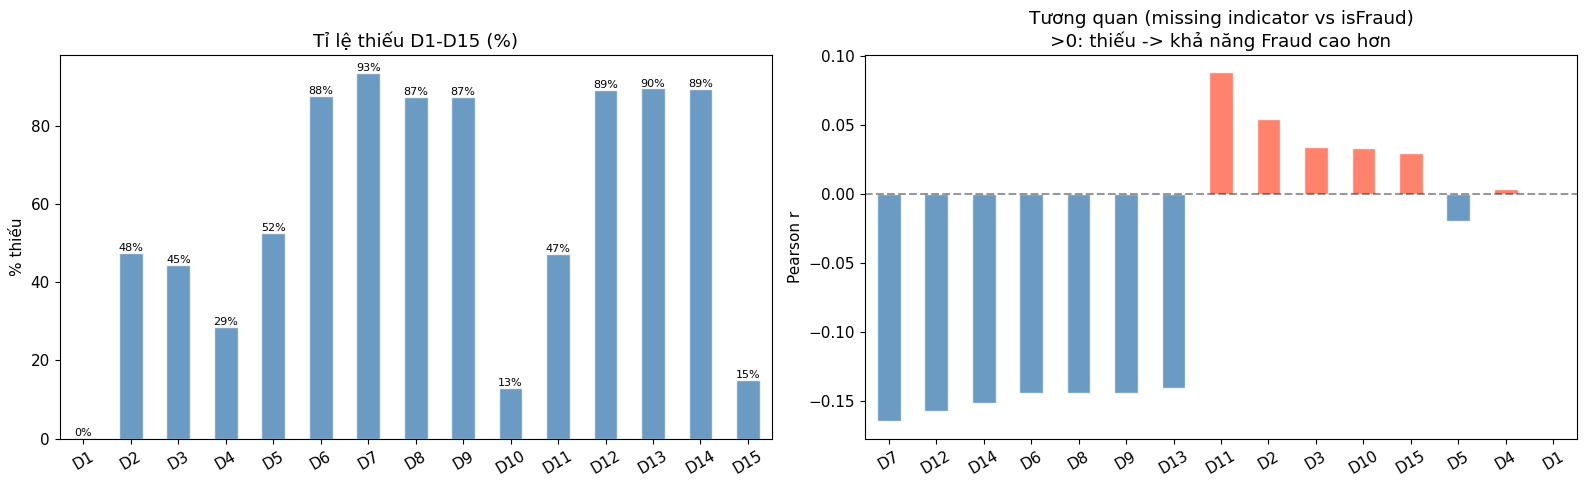

In [18]:
d_cols = [f'D{i}' for i in range(1, 16) if f'D{i}' in train.columns]

# Tỉ lệ thiếu
d_missing = train[d_cols].isnull().mean() * 100

# Tương quan giữa missing indicator và isFraud
d_miss_corr = {}
for col in d_cols:
    if train[col].isnull().any():
        indicator = train[col].isnull().astype(int)
        d_miss_corr[col] = indicator.corr(train['isFraud'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

d_missing.plot(
    kind='bar', ax=axes[0], color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_title('Tỉ lệ thiếu D1-D15 (%)')
axes[0].set_ylabel('% thiếu')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(d_missing.values):
    axes[0].text(i, v + 0.5, f'{v:.0f}%', ha='center', fontsize=8)

corr_series = pd.Series(d_miss_corr).sort_values(key=abs, ascending=False)
corr_series.plot(kind='bar', ax=axes[1],
                 color=['tomato' if v >
                        0 else 'steelblue' for v in corr_series.values],
                 alpha=0.8, edgecolor='white')
axes[1].axhline(0, color='black', linestyle='--', alpha=0.4)
axes[1].set_title(
    'Tương quan (missing indicator vs isFraud)\n>0: thiếu -> khả năng Fraud cao hơn')
axes[1].set_ylabel('Pearson r')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda_08_d_cols.png'),
            dpi=100, bbox_inches='tight')
plt.show()

#### Identity: id_01, id_02 và tác động của việc CÓ/KHÔNG có identity

Fraud rate theo có/không có identity record:
  Không có identity (0): 2.09%
  Có identity     (1): 7.85%


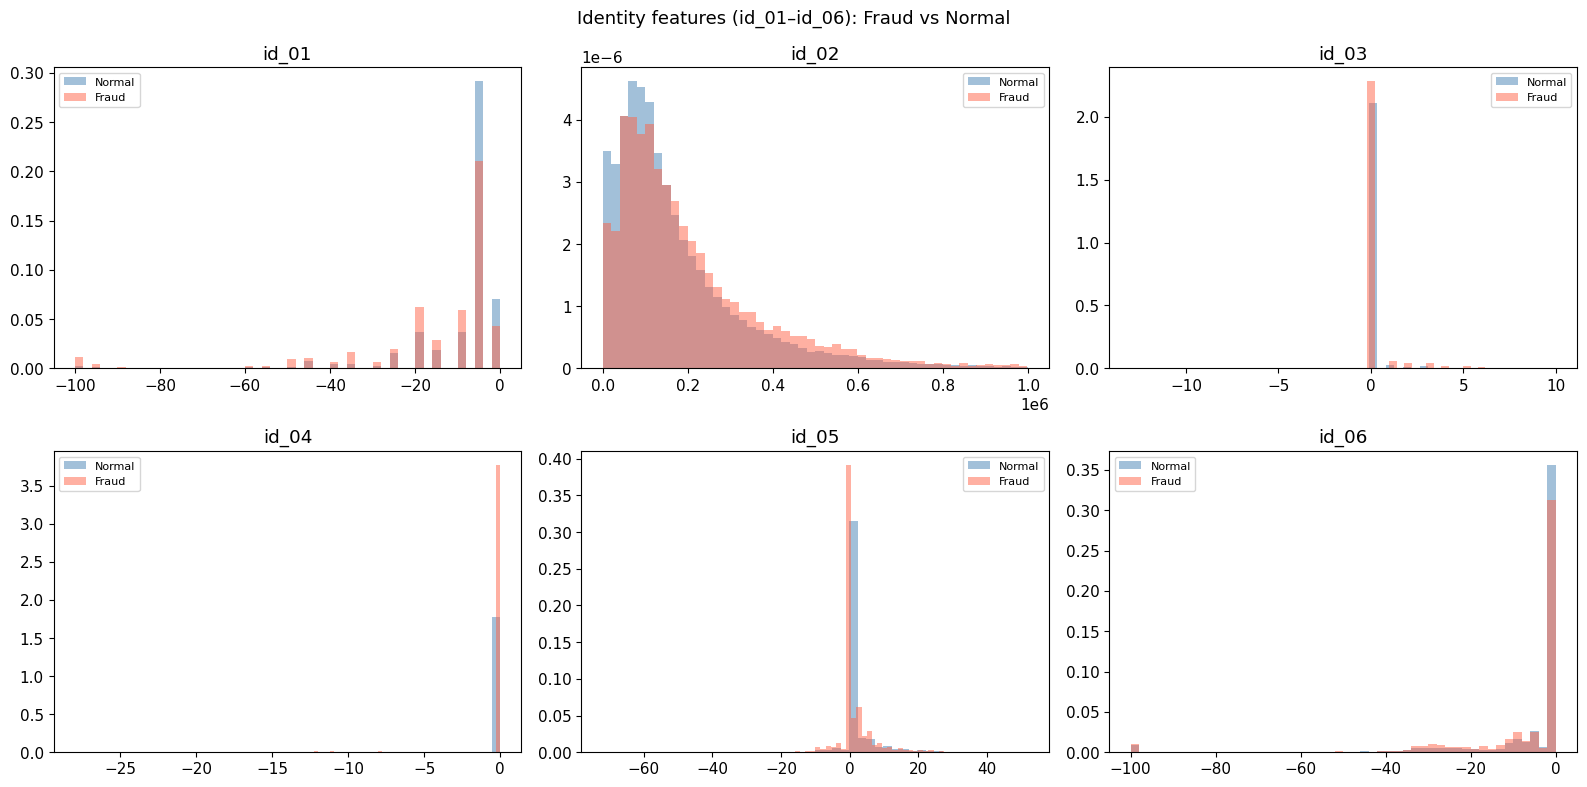

In [19]:
# Tác động của việc có identity record
train['has_identity'] = (~train['id_01'].isnull()).astype(int)
id_fraud_rate = train.groupby('has_identity')['isFraud'].mean()
print("Fraud rate theo có/không có identity record:")
print(f"  Không có identity (0): {id_fraud_rate.get(0, 0)*100:.2f}%")
print(f"  Có identity     (1): {id_fraud_rate.get(1, 0)*100:.2f}%")
train.drop(columns=['has_identity'], inplace=True)

# id_01, id_02 distribution
id_num_cols = [c for c in ['id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06']
               if c in train.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(id_num_cols):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        data = train[train['isFraud'] == label][col].dropna()
        axes[i].hist(data, bins=50, alpha=0.5, color=color, density=True,
                     label=f'{"Fraud" if label else "Normal"}')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Identity features (id_01–id_06): Fraud vs Normal', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'eda_09_identity.png'),
            dpi=100, bbox_inches='tight')
plt.show()

#### Nhận xét: Identity features (id_01–id_06)

Fraud rate theo có/không có identity record:
| | Fraud rate |
|---|---|
| Không có identity | 2.09% |
| Có identity | **7.85%** |

Giao dịch có identity record có fraud rate cao gấp ~3.75 lần so với không có. Điều này có vẻ ngược với trực giác, nhưng lý giải được: fraud thường xảy ra trên các thiết bị/trình duyệt được nhận dạng (có identity), trong khi các giao dịch không có identity phần lớn là các kênh thanh toán đơn giản ít bị tấn công hơn. Feature `has_identity` (1/0) vì vậy là tín hiệu phân biệt tốt và nên tạo trong pipeline.

Phân phối id_01–id_06:

- **id_01:** Fraud tập trung ở vùng âm (-20 đến 0), Normal tập trung ở 0 — hai lớp có phân phối khác biệt rõ, feature phân biệt tốt
- **id_02:** Cả hai lớp lệch phải mạnh (phần lớn < 0.2 triệu), nhưng Fraud có đuôi dài hơn về phía giá trị lớn
- **id_03:** Cả hai lớp đều tập trung cực kỳ hẹp quanh 0, phân phối gần như giống nhau — tín hiệu yếu
- **id_04:** Fraud trải rộng hơn về phía âm, Normal tập trung ở 0
- **id_05:** Fraud có đỉnh thứ hai ở vùng âm xa (-60), Normal gần như chỉ có đỉnh tại 0
- **id_06:** Tương tự id_05, Fraud trải về phía âm trong khi Normal tập trung ở 0

`id_01`, `id_04`, `id_05`, `id_06` có phân phối khác biệt rõ giữa Fraud và Normal — là các feature có giá trị. `id_03` tín hiệu yếu hơn. Tất cả đều có phân phối lệch mạnh và nhiều giá trị âm bất thường -> cần RobustScaler hoặc log-transform sau khi xử lý missing.

---